# End-to-End EDA chuyên sâu: Data Understanding, Data Quality, Revenue & Profit

Notebook này bám theo `report_28_5_2026/plan.md`, nhưng triển khai theo hướng phân tích sâu: mỗi mục lớn có nhiều bảng kết quả, biểu đồ và kết luận. Code trong từng cell được giữ ngắn; độ sâu nằm ở số lượng kiểm tra, lát cắt phân tích và diễn giải.

## 0. Setup

Cell này chỉ chuẩn bị thư viện, metadata nghiệp vụ và cấu hình hiển thị. Các phần phân tích bên dưới được tách thành nhiều cell nhỏ để dễ đọc, dễ chạy lại và dễ thuyết trình.

<!-- cell-note -->
**Mô tả cell:** Import các thư viện chính và tắt bớt warning để notebook chạy gọn. Cell này cũng chuẩn bị các package dùng cho bảng, biểu đồ và xử lý ngày tháng.


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = lambda text: text
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False})

<!-- cell-note -->
**Mô tả cell:** Khai báo đường dẫn dữ liệu, nhóm bảng và các cột ngày/khóa quan trọng. Đây là metadata nền để các bước sau hiểu đúng vai trò từng bảng.


In [5]:
DATA_DIR = Path("/kaggle/input/datasets/cuccu123456/datathon")

TABLE_GROUPS = {
    "master/dimension": ["products", "customers", "promotions", "geography"],
    "transaction/fact": ["orders", "order_items", "payments", "shipments", "returns", "reviews"],
    "analytical": ["sales", "sample_submission"],
    "operational/log": ["inventory", "web_traffic"],
}
DATE_COLS = {
    "customers": ["signup_date"], "promotions": ["start_date", "end_date"], "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"], "returns": ["return_date"], "reviews": ["review_date"],
    "sales": ["Date"], "sample_submission": ["Date"], "inventory": ["snapshot_date"], "web_traffic": ["date"],
}
PK = {
    "products": ["product_id"], "customers": ["customer_id"], "geography": ["zip"], "promotions": ["promo_id"],
    "orders": ["order_id"], "order_items": ["order_id", "product_id"], "payments": ["order_id"],
    "shipments": ["order_id"], "returns": ["return_id"], "reviews": ["review_id"],
    "inventory": ["snapshot_date", "product_id"], "sales": ["Date"], "sample_submission": ["Date"],
    "web_traffic": ["date", "traffic_source"],
}

<!-- cell-note -->
**Mô tả cell:** Định nghĩa ý nghĩa nghiệp vụ và grain của từng bảng. Phần này giúp người đọc biết mỗi dòng dữ liệu đại diện cho đối tượng nào.


In [6]:
MEANING = {
    "orders": "Thông tin tổng quan đơn hàng", "order_items": "Chi tiết sản phẩm trong đơn", "products": "Danh mục sản phẩm/SKU",
    "customers": "Hồ sơ khách hàng", "payments": "Thanh toán", "shipments": "Vận chuyển", "returns": "Hoàn hàng/hoàn tiền",
    "reviews": "Đánh giá sau mua", "promotions": "Khuyến mãi", "geography": "Khu vực/zip", "sales": "Revenue/COGS theo ngày",
    "sample_submission": "Mẫu nộp dự báo", "inventory": "Tồn kho", "web_traffic": "Traffic website",
}
GRAIN = {
    "orders": "1 dòng = 1 đơn hàng", "order_items": "1 dòng = 1 sản phẩm trong 1 đơn", "products": "1 dòng = 1 SKU",
    "customers": "1 dòng = 1 khách hàng", "payments": "1 dòng = thanh toán của 1 đơn", "shipments": "1 dòng = vận chuyển của 1 đơn",
    "returns": "1 dòng = 1 sự kiện hoàn hàng", "reviews": "1 dòng = 1 đánh giá", "promotions": "1 dòng = 1 mã/chương trình",
    "geography": "1 dòng = 1 zip/khu vực", "sales": "1 dòng = 1 ngày", "inventory": "1 dòng = snapshot sản phẩm", "web_traffic": "1 dòng = ngày x nguồn traffic",
}
FK_CHECKS = [
    ("orders", "customer_id", "customers", "customer_id", False), ("orders", "zip", "geography", "zip", False),
    ("order_items", "order_id", "orders", "order_id", False), ("order_items", "product_id", "products", "product_id", False),
    ("order_items", "promo_id", "promotions", "promo_id", True), ("order_items", "promo_id_2", "promotions", "promo_id", True),
    ("payments", "order_id", "orders", "order_id", False), ("shipments", "order_id", "orders", "order_id", False),
    ("returns", "order_id", "orders", "order_id", False), ("returns", "product_id", "products", "product_id", False),
    ("reviews", "order_id", "orders", "order_id", False), ("reviews", "product_id", "products", "product_id", False),
    ("inventory", "product_id", "products", "product_id", False),
]

<!-- cell-note -->
**Mô tả cell:** Chuẩn bị formatter cho tiền, phần trăm và số lượng trên biểu đồ. Nhờ vậy các chart phía sau dễ đọc hơn thay vì hiển thị số quá dài.


In [7]:
money = FuncFormatter(lambda x, _: f"{x/1e9:.1f}B" if abs(x) >= 1e9 else f"{x/1e6:.0f}M" if abs(x) >= 1e6 else f"{x/1e3:.0f}K" if abs(x) >= 1e3 else f"{x:.0f}")
pct_axis = FuncFormatter(lambda x, _: f"{x:.0%}" if abs(x) <= 1 else f"{x:.0f}%")
count_axis = FuncFormatter(lambda x, _: f"{x:,.0f}")

group_of = lambda table: next((g for g, names in TABLE_GROUPS.items() if table in names), "unknown")
month_start = lambda s: s.dt.to_period("M").dt.to_timestamp()
week_start = lambda s: s.dt.to_period("W-SUN").dt.start_time
def safe_div(a, b): return np.where(b != 0, a / b, np.nan)

<!-- cell-note -->
**Mô tả cell:** Tạo các hàm helper để vẽ bar chart, lưu hình và in kết luận dạng note. Những hàm này được tái sử dụng xuyên suốt notebook để giảm lặp code.


In [8]:
def barh(df, x, y, title, top=None, hue=None, formatter=money, figsize=(9, 4.8)):
    d = df.nlargest(top, x) if top else df.copy()
    d = d.sort_values(x)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=d, x=x, y=y, hue=hue, dodge=False, ax=ax, palette="tab10")
    ax.set(title=title, xlabel=x, ylabel="")
    ax.xaxis.set_major_formatter(formatter)
    if hue: ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()

def show_note(title, bullets):
    text = "**" + title + "**\n" + "\n".join([f"- {b}" for b in bullets])
    display(Markdown(text))

def rule_result(rule, checked, mask, severity="HIGH", note=""):
    issues = int(mask.fillna(False).sum()) if checked else 0
    return {"rule": rule, "checked_rows": checked, "issue_count": issues, "issue_pct": round(issues / checked * 100, 3) if checked else 0, "severity": "PASS" if issues == 0 else severity, "note": "pass" if issues == 0 else note}

## Bước 1 — Hiểu dữ liệu + hiểu nghiệp vụ

Mục tiêu của bước này là dựng bản đồ dữ liệu trước khi phân tích: có bao nhiêu bảng, bảng nào là fact/dimension, một dòng trong mỗi bảng nghĩa là gì, join bằng khóa nào, và các hướng phân tích kinh doanh khả thi.

<!-- cell-note -->
**Mô tả cell:** Load toàn bộ file CSV vào dictionary `tables` và tự động ép kiểu các cột ngày. Đây là bước đưa dữ liệu thô vào notebook theo cấu trúc dùng chung.


In [9]:
def load_tables(data_dir=DATA_DIR):
    loaded = {p.stem: pd.read_csv(p, low_memory=False) for p in sorted(data_dir.glob("*.csv"))}
    for table, cols in DATE_COLS.items():
        if table in loaded:
            for col in cols:
                if col in loaded[table]:
                    loaded[table][col] = pd.to_datetime(loaded[table][col], errors="coerce")
    return loaded

tables = load_tables()
print(f"Loaded {len(tables)} tables from {DATA_DIR}")

Loaded 14 tables from /kaggle/input/datasets/cuccu123456/datathon


<!-- cell-note -->
**Mô tả cell:** Tạo data catalog cho tất cả bảng: nhóm dữ liệu, số dòng, số cột, khóa chính và cột ngày. Bảng này là bản đồ tổng quan đầu tiên của dataset.


In [10]:
catalog = pd.DataFrame([
    {"table": t, "business_meaning": MEANING.get(t, ""), "group": group_of(t), "rows": len(df), "columns": df.shape[1], "primary_key": ", ".join(PK.get(t, [])), "date_cols": ", ".join([c for c in DATE_COLS.get(t, []) if c in df])}
    for t, df in tables.items()
]).sort_values(["group", "table"])
display(catalog)

,table,business_meaning,group,rows,columns,primary_key,date_cols
10,sales,Revenue/COGS theo ngày,analytical,3833,3,Date,Date
11,sample_submission,Mẫu nộp dự báo,analytical,548,3,Date,Date
0,customers,Hồ sơ khách hàng,master/dimension,121930,7,customer_id,signup_date
1,geography,Khu vực/zip,master/dimension,39948,4,zip,
6,products,Danh mục sản phẩm/SKU,master/dimension,2412,8,product_id,
7,promotions,Khuyến mãi,master/dimension,50,10,promo_id,"start_date, end_date"
2,inventory,Tồn kho,operational/log,60247,17,"snapshot_date, product_id",snapshot_date
13,web_traffic,Traffic website,operational/log,3652,7,"date, traffic_source",date
3,order_items,Chi tiết sản phẩm trong đơn,transaction/fact,714669,7,"order_id, product_id",
4,orders,Thông tin tổng quan đơn hàng,transaction/fact,646945,8,order_id,order_date


<!-- cell-note -->
**Mô tả cell:** Vẽ nhanh quy mô từng bảng theo số dòng và số cột. Mục tiêu là nhận diện bảng fact lớn, bảng dimension nhỏ và bảng operational phụ trợ.


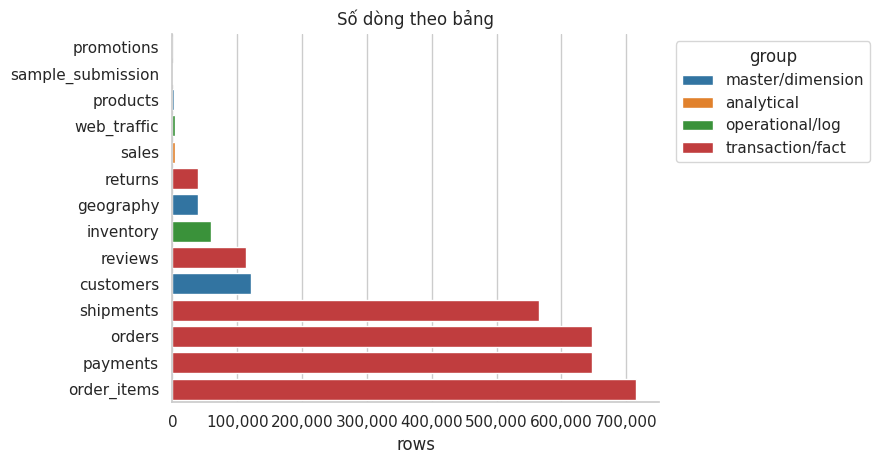

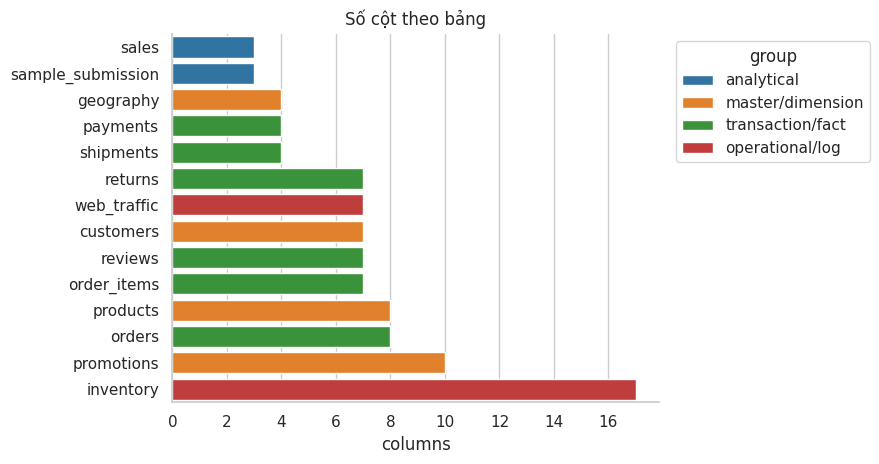

In [11]:
barh(catalog, "rows", "table", "Số dòng theo bảng", hue="group", formatter=count_axis)
barh(catalog, "columns", "table", "Số cột theo bảng", hue="group", formatter=count_axis)

<!-- cell-note -->
**Mô tả cell:** Phân loại semantic type cho từng cột như date, id, categorical, numeric. Kết quả này dùng để hiểu schema sâu hơn dtype thô của pandas.


In [12]:
def semantic_type(table, col, s):
    c, n = col.lower(), s.nunique(dropna=True)
    if col in DATE_COLS.get(table, []) or "date" in c: return "date"
    if c.endswith("_id") or c in {"id", "zip"}: return "id"
    if pd.api.types.is_bool_dtype(s) or s.dropna().isin([0, 1, True, False, "yes", "no", "Yes", "No"]).all(): return "boolean"
    if pd.api.types.is_numeric_dtype(s): return "numeric_discrete" if n <= 20 else "numeric_continuous"
    return "categorical_low" if n <= 30 else "categorical_high"

schema = pd.DataFrame([{"table": t, "column": c, "semantic_type": semantic_type(t, c, df[c]), "dtype": str(df[c].dtype), "missing_pct": round(df[c].isna().mean() * 100, 3), "unique": int(df[c].nunique(dropna=True))} for t, df in tables.items() for c in df.columns])
display(schema.sort_values(["table", "column"]))

,table,column,semantic_type,dtype,missing_pct,unique
6,customers,acquisition_channel,categorical_low,object,0.0,6
5,customers,age_group,categorical_low,object,0.0,5
2,customers,city,categorical_high,object,0.0,42
0,customers,customer_id,id,int64,0.0,121930
4,customers,gender,categorical_low,object,0.0,3
...,...,...,...,...,...,...
89,web_traffic,date,date,datetime64[ns],0.0,3652
92,web_traffic,page_views,numeric_continuous,int64,0.0,3620
90,web_traffic,sessions,numeric_continuous,int64,0.0,3447
95,web_traffic,traffic_source,categorical_low,object,0.0,6


<!-- cell-note -->
**Mô tả cell:** Tổng hợp và trực quan hóa cơ cấu kiểu dữ liệu theo từng bảng. Cell này giúp thấy bảng nào thiên về ID, số đo, ngày tháng hay biến phân loại.


semantic_type,boolean,categorical_high,categorical_low,date,id,numeric_continuous,numeric_discrete
table,,,,,,,
customers,0,1,3,1,2,0,0
geography,0,2,1,0,1,0,0
inventory,3,1,2,1,1,7,2
order_items,0,0,1,0,3,2,1
orders,0,0,4,1,3,0,0
payments,0,0,1,0,1,1,1
products,0,1,4,0,1,2,0
promotions,1,1,3,2,1,0,2
returns,0,0,1,1,3,1,1


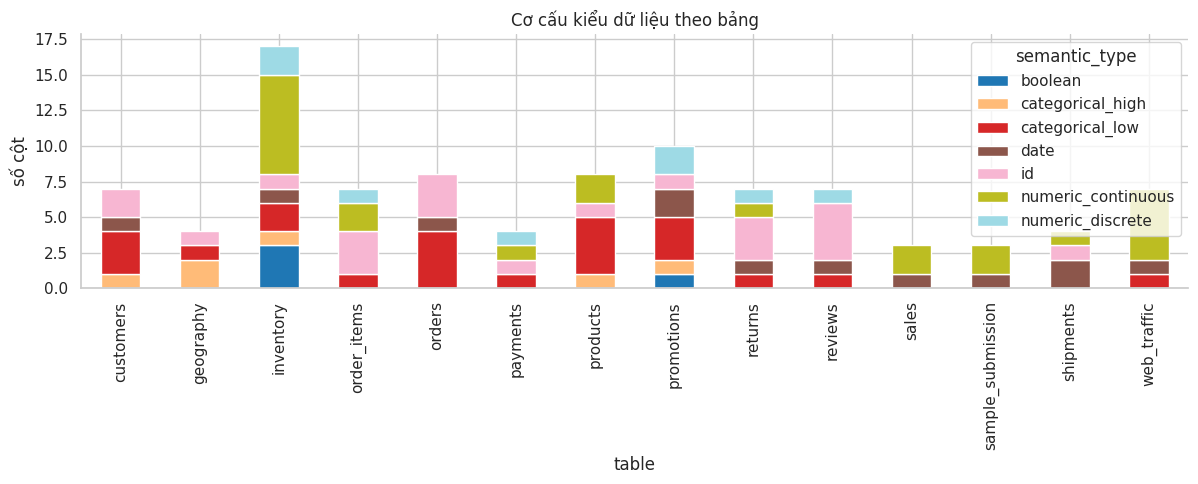

In [13]:
type_matrix = schema.groupby(["table", "semantic_type"]).size().unstack(fill_value=0)
display(type_matrix)
type_matrix.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
plt.title("Cơ cấu kiểu dữ liệu theo bảng")
plt.xlabel("table"); plt.ylabel("số cột")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Lập bảng grain cho từng dataset. Đây là bước quan trọng để tránh join sai cấp độ và làm nhân bản doanh thu.


In [14]:
grain = pd.DataFrame([{"table": t, "business_entity": MEANING.get(t, ""), "grain": GRAIN.get(t, ""), "primary_key": ", ".join(PK.get(t, []))} for t in sorted(tables)])
display(grain)

,table,business_entity,grain,primary_key
0,customers,Hồ sơ khách hàng,1 dòng = 1 khách hàng,customer_id
1,geography,Khu vực/zip,1 dòng = 1 zip/khu vực,zip
2,inventory,Tồn kho,1 dòng = snapshot sản phẩm,"snapshot_date, product_id"
3,order_items,Chi tiết sản phẩm trong đơn,1 dòng = 1 sản phẩm trong 1 đơn,"order_id, product_id"
4,orders,Thông tin tổng quan đơn hàng,1 dòng = 1 đơn hàng,order_id
5,payments,Thanh toán,1 dòng = thanh toán của 1 đơn,order_id
6,products,Danh mục sản phẩm/SKU,1 dòng = 1 SKU,product_id
7,promotions,Khuyến mãi,1 dòng = 1 mã/chương trình,promo_id
8,returns,Hoàn hàng/hoàn tiền,1 dòng = 1 sự kiện hoàn hàng,return_id
9,reviews,Đánh giá sau mua,1 dòng = 1 đánh giá,review_id


<!-- cell-note -->
**Mô tả cell:** Dựng bảng quan hệ giữa các bảng chính, kèm kiểu join và ghi chú nghiệp vụ. Cell này là bản join map dùng cho các phân tích phía sau.


In [16]:
relationships = pd.DataFrame([
    ["orders", "order_id", "order_items", "order_id", "1-n", "Một đơn có nhiều dòng sản phẩm"],
    ["orders", "customer_id", "customers", "customer_id", "n-1", "Một khách có thể có nhiều đơn"],
    ["order_items", "product_id", "products", "product_id", "n-1", "Một SKU nằm trong nhiều đơn"],
    ["orders", "order_id", "payments", "order_id", "1-1", "Thanh toán theo đơn"],
    ["orders", "order_id", "shipments", "order_id", "1-0/1", "Không phải đơn nào cũng có shipment"],
    ["orders", "order_id", "returns", "order_id", "1-0/n", "Chỉ đơn return mới có record returns"],
    ["orders", "order_id", "reviews", "order_id", "1-0/n", "Không phải đơn nào cũng review"],
], columns=["left_table", "left_key", "right_table", "right_key", "relationship", "business_note"])
display(relationships)

,left_table,left_key,right_table,right_key,relationship,business_note
0,orders,order_id,order_items,order_id,1-n,Một đơn có nhiều dòng sản phẩm
1,orders,customer_id,customers,customer_id,n-1,Một khách có thể có nhiều đơn
2,order_items,product_id,products,product_id,n-1,Một SKU nằm trong nhiều đơn
3,orders,order_id,payments,order_id,1-1,Thanh toán theo đơn
4,orders,order_id,shipments,order_id,1-0/1,Không phải đơn nào cũng có shipment
5,orders,order_id,returns,order_id,1-0/n,Chỉ đơn return mới có record returns
6,orders,order_id,reviews,order_id,1-0/n,Không phải đơn nào cũng review


<!-- cell-note -->
**Mô tả cell:** Tính khoảng thời gian dữ liệu cho các cột ngày. Kết quả cho biết bảng nào phủ giai đoạn nào và có thiếu ngày hay không.


In [17]:
date_coverage = pd.DataFrame([
    {"table": t, "date_col": c, "min_date": tables[t][c].min(), "max_date": tables[t][c].max(), "unique_dates": tables[t][c].dt.normalize().nunique(), "missing_dates": int(tables[t][c].isna().sum())}
    for t, cols in DATE_COLS.items() if t in tables for c in cols if c in tables[t]
])
display(date_coverage.sort_values("min_date"))

,table,date_col,min_date,max_date,unique_dates,missing_dates
0,customers,signup_date,2012-01-17,2022-12-31,3941,0
3,orders,order_date,2012-07-04,2022-12-31,3833,0
4,shipments,ship_date,2012-07-04,2022-12-29,3831,0
8,sales,Date,2012-07-04,2022-12-31,3833,0
5,shipments,delivery_date,2012-07-06,2022-12-31,3831,0
7,reviews,review_date,2012-07-10,2022-12-31,3825,0
6,returns,return_date,2012-07-11,2022-12-31,3806,0
10,inventory,snapshot_date,2012-07-31,2022-12-31,126,0
11,web_traffic,date,2013-01-01,2022-12-31,3652,0
1,promotions,start_date,2013-01-31,2022-11-18,50,0


<!-- cell-note -->
**Mô tả cell:** Vẽ timeline coverage cho các bảng có cột ngày. Biểu đồ giúp so sánh trực quan phạm vi thời gian giữa sales, orders, traffic, inventory và các bảng khác.


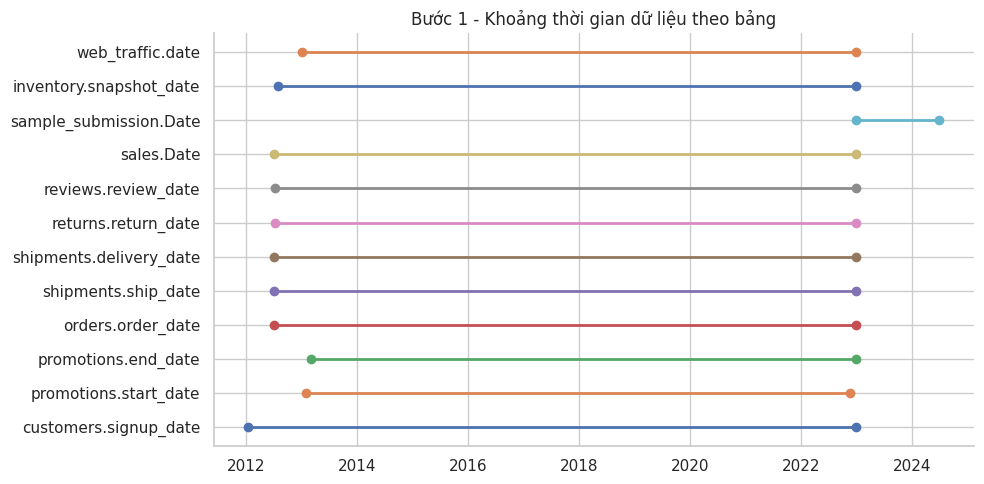

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_dates = date_coverage.dropna(subset=["min_date", "max_date"]).copy()
for i, r in plot_dates.reset_index(drop=True).iterrows():
    ax.plot([r.min_date, r.max_date], [i, i], marker="o", linewidth=2)
ax.set_yticks(range(len(plot_dates))); ax.set_yticklabels(plot_dates["table"] + "." + plot_dates["date_col"])
ax.set_title("Bước 1 - Khoảng thời gian dữ liệu theo bảng")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Ánh xạ dataset sang các nhóm bài toán kinh doanh khả thi. Cell này chuyển từ hiểu cấu trúc dữ liệu sang định hướng phân tích.


In [19]:
business_map = pd.DataFrame([
    ["Doanh thu", "Revenue trend, AOV, revenue by category/channel", "sales, orders, order_items, products"],
    ["Lợi nhuận", "Profit, margin, cost impact", "order_items, products"],
    ["Khách hàng", "Repeat purchase, RFM, retention", "customers, orders"],
    ["Sản phẩm", "Best sellers, product margin, return rate", "products, order_items, returns"],
    ["Đơn hàng", "Status, cancellation, lifecycle", "orders, payments, shipments"],
    ["Vận chuyển", "Delivery time, late delivery", "shipments, orders"],
    ["Hoàn trả", "Return rate, refund loss", "returns, order_items"],
    ["Review", "Rating, satisfaction", "reviews, products"],
], columns=["business_area", "possible_analysis", "main_tables"])
display(business_map)

,business_area,possible_analysis,main_tables
0,Doanh thu,"Revenue trend, AOV, revenue by category/channel","sales, orders, order_items, products"
1,Lợi nhuận,"Profit, margin, cost impact","order_items, products"
2,Khách hàng,"Repeat purchase, RFM, retention","customers, orders"
3,Sản phẩm,"Best sellers, product margin, return rate","products, order_items, returns"
4,Đơn hàng,"Status, cancellation, lifecycle","orders, payments, shipments"
5,Vận chuyển,"Delivery time, late delivery","shipments, orders"
6,Hoàn trả,"Return rate, refund loss","returns, order_items"
7,Review,"Rating, satisfaction","reviews, products"


<!-- cell-note -->
**Mô tả cell:** Kiểm tra nhanh phân bố các biến phân loại quan trọng như order status, payment method và category. Đây là EDA nền trước khi đi sâu revenue/profit.


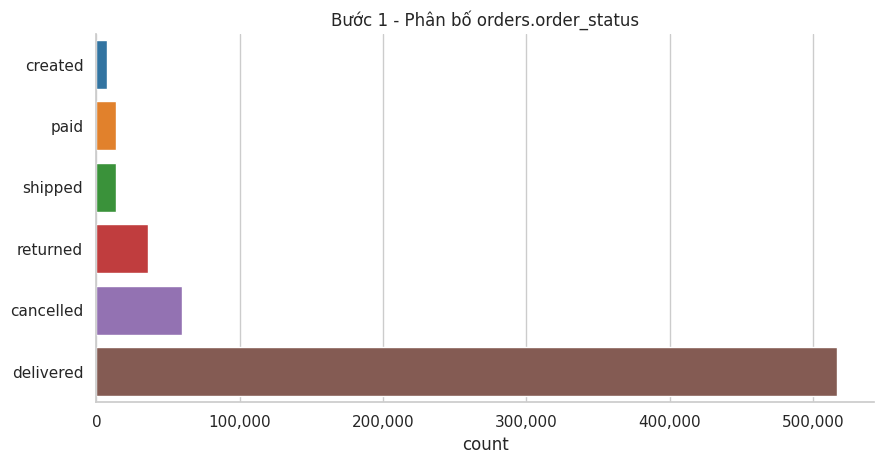

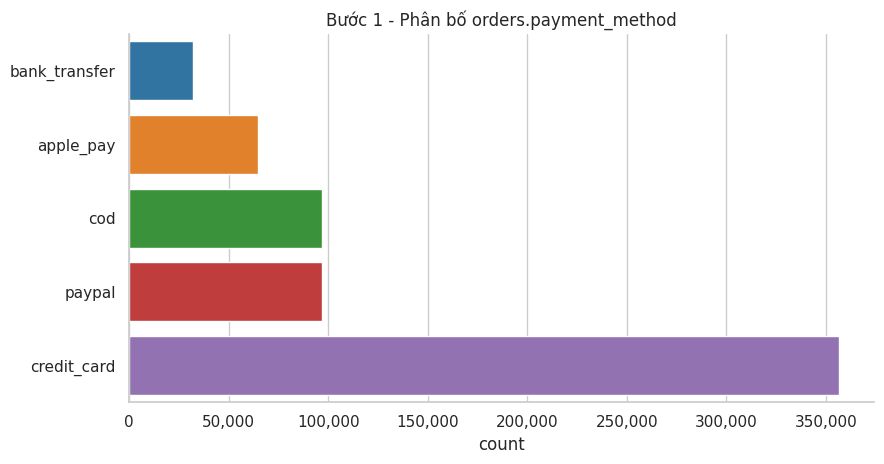

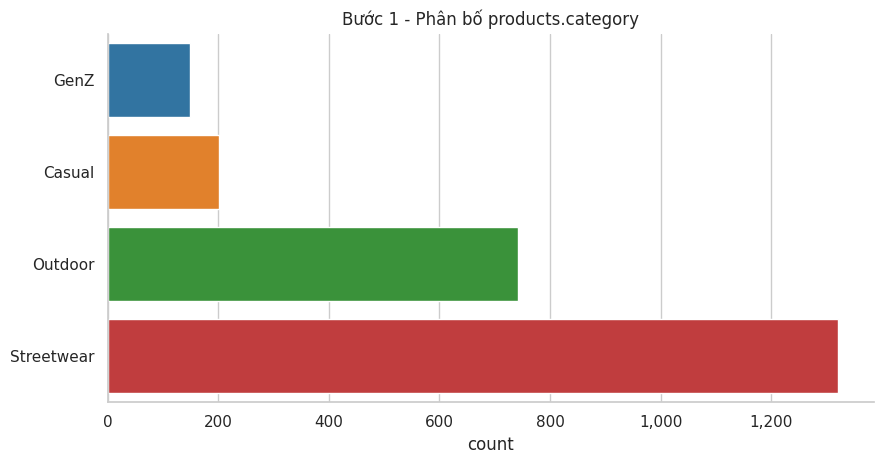

In [20]:
for table, col in [("orders", "order_status"), ("orders", "payment_method"), ("products", "category")]:
    if table in tables and col in tables[table]:
        counts = tables[table][col].value_counts().reset_index()
        counts.columns = [col, "count"]
        barh(counts, "count", col, f"Bước 1 - Phân bố {table}.{col}", formatter=count_axis)

<!-- cell-note -->
**Mô tả cell:** Tổng kết Bước 1 bằng các nhận định chính về domain, bảng trung tâm và nguyên tắc join. Phần note này giúp người đọc chốt lại logic dữ liệu trước khi qua quality check.


In [21]:
show_note("Kết luận Bước 1", [
    "Dataset thuộc lĩnh vực ecommerce/retail, mô tả vòng đời đơn hàng từ đặt hàng, thanh toán, vận chuyển, hoàn hàng đến đánh giá.",
    "orders là bảng trung tâm cấp đơn; order_items là bảng chi tiết sản phẩm nên phải aggregate theo order_id trước khi join vào orders.",
    "Revenue & Profit là hướng ưu tiên vì có quantity, unit_price, discount_amount, refund_amount và cogs/cost.",
])

**Kết luận Bước 1**
- Dataset thuộc lĩnh vực ecommerce/retail, mô tả vòng đời đơn hàng từ đặt hàng, thanh toán, vận chuyển, hoàn hàng đến đánh giá.
- orders là bảng trung tâm cấp đơn; order_items là bảng chi tiết sản phẩm nên phải aggregate theo order_id trước khi join vào orders.
- Revenue & Profit là hướng ưu tiên vì có quantity, unit_price, discount_amount, refund_amount và cogs/cost.

## Bước 2 — Kiểm tra chất lượng dữ liệu

Bước này không nhằm tìm insight kinh doanh, mà để trả lời dữ liệu có đủ sạch, đúng và đáng tin để phân tích không. Các lỗi được flag theo severity và quyết định xử lý.

<!-- cell-note -->
**Mô tả cell:** Định nghĩa cách phân loại missing value theo ngữ cảnh nghiệp vụ. Cell này tách missing hợp lệ như không dùng promo khỏi missing đáng nghi cần review.


In [23]:
def missing_decision(table, col, pct):
    if pct == 0: return "pass"
    if (table, col) in {("order_items", "promo_id"), ("order_items", "promo_id_2")}: return "business-valid: no promotion"
    if table == "sample_submission" and col in {"Revenue", "COGS"}: return "business-valid: forecast placeholder"
    if col.endswith("_id") or col in {"order_id", "customer_id", "product_id", "quantity", "unit_price", "Revenue", "COGS"}: return "critical: investigate"
    return "flag before use"

missing = schema.query("missing_pct > 0").copy()
missing["decision"] = [missing_decision(r.table, r.column, r.missing_pct) for r in missing.itertuples()]
display(missing.sort_values("missing_pct", ascending=False))

,table,column,semantic_type,dtype,missing_pct,unique,decision
34,order_items,promo_id_2,categorical_low,object,99.971,2,business-valid: no promotion
61,promotions,applicable_category,categorical_low,object,80.000,2,flag before use
33,order_items,promo_id,id,object,61.337,50,business-valid: no promotion


<!-- cell-note -->
**Mô tả cell:** Vẽ top cột có tỷ lệ missing cao nhất. Biểu đồ giúp ưu tiên kiểm tra các cột có rủi ro chất lượng dữ liệu lớn.


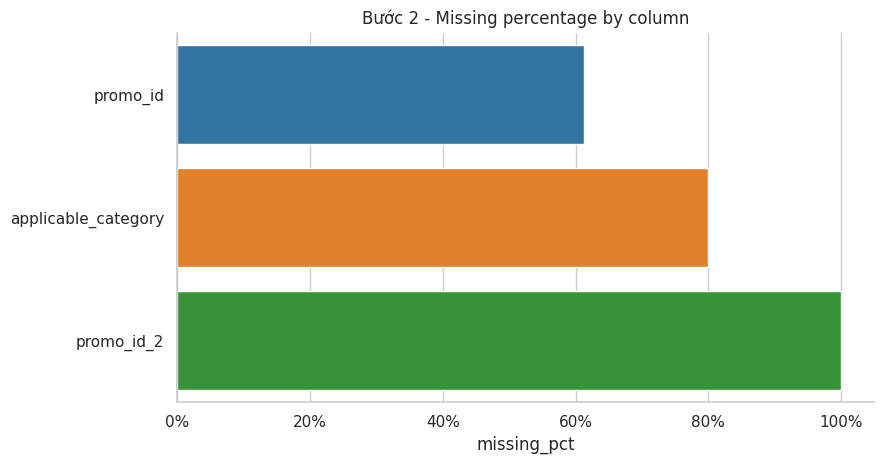

In [24]:
if len(missing):
    barh(missing, "missing_pct", "column", "Bước 2 - Missing percentage by column", top=min(20, len(missing)), formatter=FuncFormatter(lambda x, _: f"{x:.0f}%"))

<!-- cell-note -->
**Mô tả cell:** Tạo bảng missing pattern cho các bảng có nhiều cột bị thiếu. Mục tiêu là xem các giá trị trống có xuất hiện theo cụm logic hay không.


In [25]:
missing_pattern = []
for table in ["orders", "order_items", "returns", "reviews", "promotions"]:
    if table in tables:
        miss_cols = [c for c in tables[table].columns if tables[table][c].isna().any()]
        if miss_cols:
            pattern = tables[table][miss_cols].isna().astype(int).value_counts().reset_index(name="rows")
            pattern.insert(0, "table", table)
            missing_pattern.append(pattern.head(10))
missing_pattern = pd.concat(missing_pattern, ignore_index=True) if missing_pattern else pd.DataFrame()
display(missing_pattern)

,table,promo_id,promo_id_2,rows,applicable_category
0,order_items,1.0,1.0,438353,NaN
1,order_items,0.0,1.0,276110,NaN
2,order_items,0.0,0.0,206,NaN
3,promotions,NaN,NaN,40,1.0
4,promotions,NaN,NaN,10,0.0


<!-- cell-note -->
**Mô tả cell:** Kiểm tra duplicate toàn dòng trong từng bảng. Đây là kiểm tra cơ bản để phát hiện bản ghi bị nhân đôi hoàn toàn.


In [26]:
dup_full = pd.DataFrame([{"table": t, "rows": len(df), "duplicate_full_rows": int(df.duplicated().sum()), "duplicate_full_pct": round(df.duplicated().mean() * 100, 4)} for t, df in tables.items()])
display(dup_full.sort_values("duplicate_full_rows", ascending=False))

,table,rows,duplicate_full_rows,duplicate_full_pct
0,customers,121930,0,0.0
1,geography,39948,0,0.0
2,inventory,60247,0,0.0
3,order_items,714669,0,0.0
4,orders,646945,0,0.0
5,payments,646945,0,0.0
6,products,2412,0,0.0
7,promotions,50,0,0.0
8,returns,39939,0,0.0
9,reviews,113551,0,0.0


<!-- cell-note -->
**Mô tả cell:** Kiểm tra duplicate theo khóa chính hoặc khóa grain kỳ vọng. Cell này phân biệt trùng khóa là lỗi hay chỉ là dấu hiệu bảng có grain nhiều-dòng.


In [27]:
key_summary = pd.DataFrame([
    {"table": t, "key_columns": ", ".join(cols), "rows": len(tables[t]), "unique_keys": tables[t][cols].drop_duplicates().shape[0], "duplicate_key_rows": int(tables[t].duplicated(cols).sum()), "status": "PASS" if int(tables[t].duplicated(cols).sum()) == 0 else "CHECK GRAIN"}
    for t, cols in PK.items() if t in tables and all(c in tables[t] for c in cols)
])
display(key_summary.sort_values("duplicate_key_rows", ascending=False))

,table,key_columns,rows,unique_keys,duplicate_key_rows,status
5,order_items,"order_id, product_id",714669,714653,16,CHECK GRAIN
0,products,product_id,2412,2412,0,PASS
1,customers,customer_id,121930,121930,0,PASS
2,geography,zip,39948,39948,0,PASS
3,promotions,promo_id,50,50,0,PASS
4,orders,order_id,646945,646945,0,PASS
6,payments,order_id,646945,646945,0,PASS
7,shipments,order_id,566067,566067,0,PASS
8,returns,return_id,39939,39939,0,PASS
9,reviews,review_id,113551,113551,0,PASS


<!-- cell-note -->
**Mô tả cell:** Audit dtype so với semantic type đã suy luận. Cell này flag các cột ngày, số hoặc ID có kiểu dữ liệu chưa phù hợp để chuẩn hóa trước phân tích.


In [28]:
# Check lại có vẻ trùng
dtype_audit = schema.assign(dtype_note=np.select([
    schema.semantic_type.eq("date") & ~schema.dtype.str.contains("datetime"),
    schema.semantic_type.str.startswith("numeric") & ~schema.dtype.str.contains("int|float"),
    schema.semantic_type.eq("id") & schema.dtype.str.contains("int|float"),
], ["date should be datetime", "numeric should be numeric", "ID is numeric but should not be averaged"], default="ok"))
display(dtype_audit.sort_values(["dtype_note", "table", "column"]))

,table,column,semantic_type,dtype,missing_pct,unique,dtype_note
0,customers,customer_id,id,int64,0.0,121930,ID is numeric but should not be averaged
1,customers,zip,id,int64,0.0,31491,ID is numeric but should not be averaged
7,geography,zip,id,int64,0.0,39948,ID is numeric but should not be averaged
12,inventory,product_id,id,int64,0.0,1624,ID is numeric but should not be averaged
28,order_items,order_id,id,int64,0.0,646945,ID is numeric but should not be averaged
...,...,...,...,...,...,...,...
89,web_traffic,date,date,datetime64[ns],0.0,3652,ok
92,web_traffic,page_views,numeric_continuous,int64,0.0,3620,ok
90,web_traffic,sessions,numeric_continuous,int64,0.0,3447,ok
95,web_traffic,traffic_source,categorical_low,object,0.0,6,ok


<!-- cell-note -->
**Mô tả cell:** Kiểm tra toàn vẹn khóa ngoại giữa các bảng. Kết quả cho biết join có bị mất bản ghi do orphan key hay không.


In [29]:
fk_rows = []
for child, fk, parent, pk, nullable in FK_CHECKS:
    if child in tables and parent in tables and fk in tables[child] and pk in tables[parent]:
        s = tables[child][fk]
        checked = s.notna() if nullable else pd.Series(True, index=s.index)
        orphan = checked & ~s.isin(set(tables[parent][pk].dropna()))
        fk_rows.append(rule_result(f"{child}.{fk} -> {parent}.{pk}", int(checked.sum()), orphan, note="orphan FK"))
fk_summary = pd.DataFrame(fk_rows)
display(fk_summary)

,rule,checked_rows,issue_count,issue_pct,severity,note
0,orders.customer_id -> customers.customer_id,646945,0,0.0,PASS,pass
1,orders.zip -> geography.zip,646945,0,0.0,PASS,pass
2,order_items.order_id -> orders.order_id,714669,0,0.0,PASS,pass
3,order_items.product_id -> products.product_id,714669,0,0.0,PASS,pass
4,order_items.promo_id -> promotions.promo_id,276316,0,0.0,PASS,pass
5,order_items.promo_id_2 -> promotions.promo_id,206,0,0.0,PASS,pass
6,payments.order_id -> orders.order_id,646945,0,0.0,PASS,pass
7,shipments.order_id -> orders.order_id,566067,0,0.0,PASS,pass
8,returns.order_id -> orders.order_id,39939,0,0.0,PASS,pass
9,returns.product_id -> products.product_id,39939,0,0.0,PASS,pass


<!-- cell-note -->
**Mô tả cell:** Chạy các rule logic nghiệp vụ cho giá, COGS, quantity, discount, payment, return, rating, inventory và traffic. Đây là lớp kiểm tra đúng-sai theo business rule.


In [30]:
business_checks = [
    ("products", "price > 0", lambda d: d.price <= 0), ("products", "cogs >= 0", lambda d: d.cogs < 0),
    ("products", "price >= cogs", lambda d: d.price < d.cogs), ("order_items", "quantity > 0", lambda d: d.quantity <= 0),
    ("order_items", "unit_price > 0", lambda d: d.unit_price <= 0), ("order_items", "discount >= 0", lambda d: d.discount_amount < 0),
    ("order_items", "discount <= gross", lambda d: d.discount_amount > d.quantity * d.unit_price), ("payments", "payment_value >= 0", lambda d: d.payment_value < 0),
    ("shipments", "shipping_fee >= 0", lambda d: d.shipping_fee < 0), ("returns", "return_quantity > 0", lambda d: d.return_quantity <= 0),
    ("returns", "refund_amount >= 0", lambda d: d.refund_amount < 0), ("reviews", "rating between 1 and 5", lambda d: (d.rating < 1) | (d.rating > 5)),
]
business_rules = pd.DataFrame([rule_result(f"{t}: {name}", len(tables[t]), fn(tables[t]), note="business anomaly") for t, name, fn in business_checks if t in tables])
display(business_rules)

,rule,checked_rows,issue_count,issue_pct,severity,note
0,products: price > 0,2412,0,0.0,PASS,pass
1,products: cogs >= 0,2412,0,0.0,PASS,pass
2,products: price >= cogs,2412,0,0.0,PASS,pass
3,order_items: quantity > 0,714669,0,0.0,PASS,pass
4,order_items: unit_price > 0,714669,0,0.0,PASS,pass
5,order_items: discount >= 0,714669,0,0.0,PASS,pass
6,order_items: discount <= gross,714669,0,0.0,PASS,pass
7,payments: payment_value >= 0,646945,0,0.0,PASS,pass
8,shipments: shipping_fee >= 0,566067,0,0.0,PASS,pass
9,returns: return_quantity > 0,39939,0,0.0,PASS,pass


<!-- cell-note -->
**Mô tả cell:** Tính thống kê outlier cho các trường numeric quan trọng. Cell này dùng IQR để flag giá trị bất thường nhưng chưa vội xóa dữ liệu.


In [31]:
outlier_fields = {"products": ["price", "cogs"], "order_items": ["quantity", "unit_price", "discount_amount"], "payments": ["payment_value"], "returns": ["refund_amount"], "sales": ["Revenue", "COGS"]}
outlier_rows = []
for t, cols in outlier_fields.items():
    for c in cols:
        s = pd.to_numeric(tables[t][c], errors="coerce").dropna()
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1; lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        m = (s < lo) | (s > hi)
        outlier_rows.append({"field": f"{t}.{c}", "outlier_count": int(m.sum()), "outlier_pct": round(m.mean() * 100, 3), "p1": s.quantile(.01), "median": s.median(), "p99": s.quantile(.99), "decision": "flag only"})
outliers = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outliers)

,field,outlier_count,outlier_pct,p1,median,p99,decision
4,order_items.discount_amount,105767,14.799,0.000000,0.000000e+00,1.104115e+04,flag only
6,returns.refund_amount,2778,6.956,635.214400,7.888880e+03,6.667728e+04,flag only
5,payments.payment_value,30219,4.671,1052.668800,1.722944e+04,9.807575e+04,flag only
7,sales.Revenue,169,4.409,845078.752000,3.647304e+06,1.380199e+07,flag only
8,sales.COGS,165,4.305,738138.756000,3.161113e+06,1.157411e+07,flag only
1,products.cogs,37,1.534,9.846645,3.184934e+03,1.612482e+04,flag only
0,products.price,31,1.285,16.762233,4.399605e+03,1.953832e+04,flag only
3,order_items.unit_price,8623,1.207,627.870000,4.257770e+03,1.577848e+04,flag only
2,order_items.quantity,0,0.000,1.000000,4.000000e+00,8.000000e+00,flag only


<!-- cell-note -->
**Mô tả cell:** Vẽ tỷ lệ outlier và boxplot cho các trường tiền, discount, refund, rating. Biểu đồ giúp nhìn nhanh độ lệch và điểm cực trị của dữ liệu.


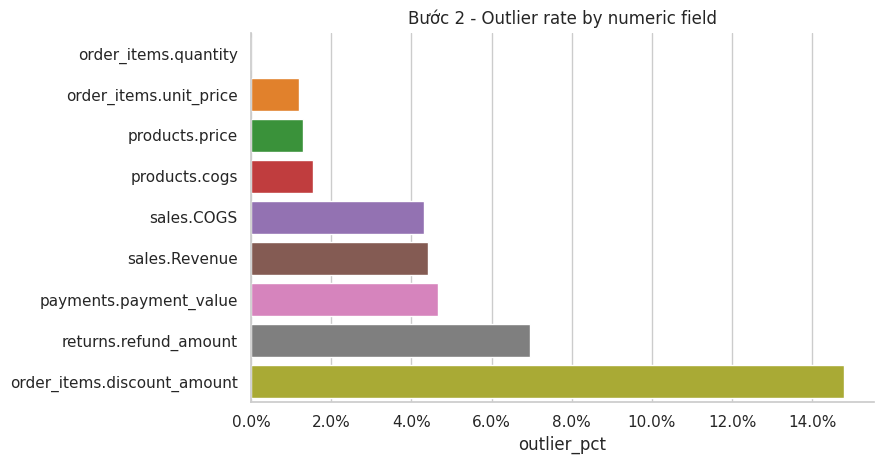

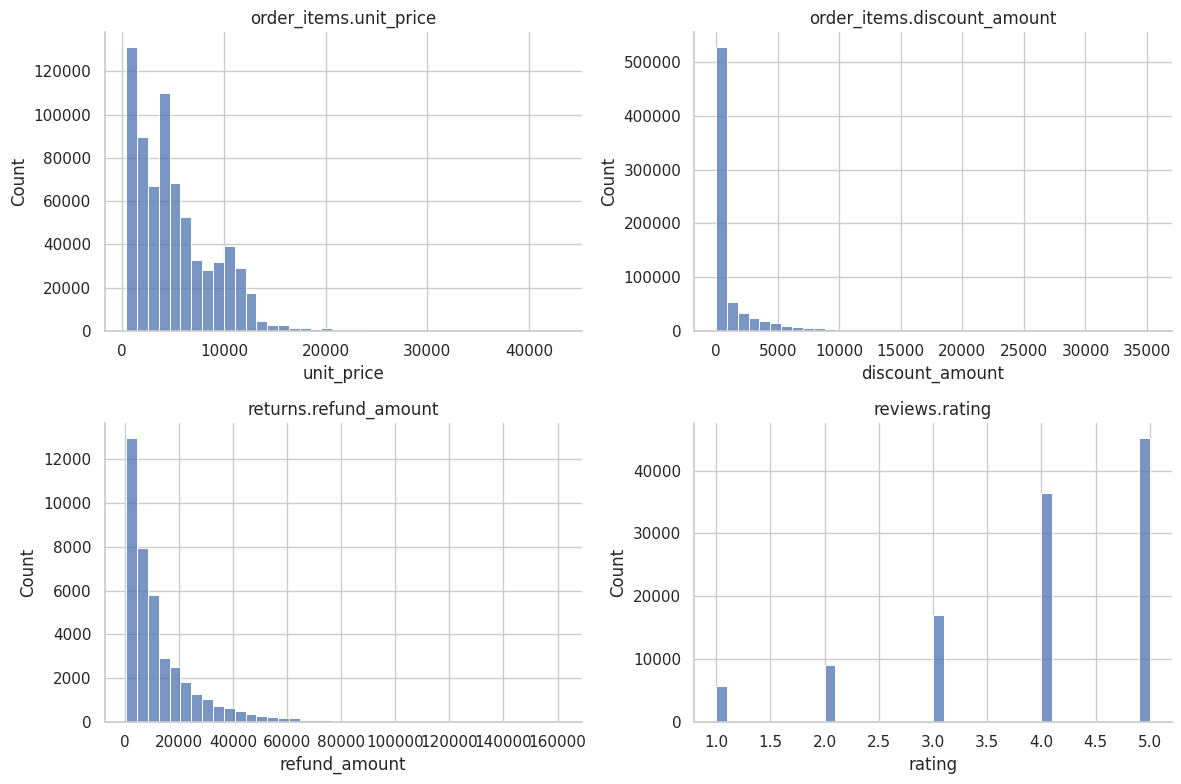

In [32]:
barh(outliers, "outlier_pct", "field", "Bước 2 - Outlier rate by numeric field", formatter=FuncFormatter(lambda x, _: f"{x:.1f}%"))
plot_fields = [("order_items", "unit_price"), ("order_items", "discount_amount"), ("returns", "refund_amount"), ("reviews", "rating")]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (t, c) in zip(axes.ravel(), plot_fields):
    sns.histplot(pd.to_numeric(tables[t][c], errors="coerce").dropna(), bins=40, ax=ax)
    ax.set_title(f"{t}.{c}")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Kiểm tra logic timeline giữa signup, order, ship, delivery, return và review. Cell này đảm bảo trình tự sự kiện không bị đảo ngược.


In [33]:
timeline_rules = []
d = tables["orders"][["order_id", "customer_id", "order_date"]].merge(tables["customers"][["customer_id", "signup_date"]], on="customer_id", how="left")
timeline_rules.append(rule_result("signup_date <= order_date", len(d), d.signup_date > d.order_date, note="signup after order"))
d = tables["shipments"].merge(tables["orders"][["order_id", "order_date"]], on="order_id", how="left")
timeline_rules += [rule_result("order_date <= ship_date", len(d), d.order_date > d.ship_date, note="ship before order"), rule_result("ship_date <= delivery_date", len(d), d.delivery_date.notna() & (d.ship_date > d.delivery_date), note="delivery before ship")]
d = tables["returns"].merge(tables["orders"][["order_id", "order_date"]], on="order_id", how="left")
timeline_rules.append(rule_result("order_date <= return_date", len(d), d.order_date > d.return_date, note="return before order"))
display(pd.DataFrame(timeline_rules))

,rule,checked_rows,issue_count,issue_pct,severity,note
0,signup_date <= order_date,646945,477453,73.801,HIGH,signup after order
1,order_date <= ship_date,566067,0,0.000,PASS,pass
2,ship_date <= delivery_date,566067,0,0.000,PASS,pass
3,order_date <= return_date,39939,0,0.000,PASS,pass


<!-- cell-note -->
**Mô tả cell:** Tạo các cờ lifecycle ở cấp order như có payment, shipment, return, review. Các flag này dùng để kiểm tra độ đầy đủ của vòng đời đơn hàng.


In [34]:
order_flags = tables["orders"][["order_id", "order_status"]].copy()
for label, df in {"payment": tables["payments"], "shipment": tables["shipments"], "return": tables["returns"], "review": tables["reviews"]}.items():
    order_flags = order_flags.merge(df[["order_id"]].drop_duplicates().assign(**{f"has_{label}": True}), on="order_id", how="left")
flag_cols = [c for c in order_flags.columns if c.startswith("has_")]
order_flags[flag_cols] = order_flags[flag_cols].fillna(False)
lifecycle = order_flags.groupby("order_status")[flag_cols].mean()
display(lifecycle)

,has_payment,has_shipment,has_return,has_review
order_status,,,,
cancelled,1.0,0.000000,0.000000,0.000000
created,1.0,0.000000,0.000000,0.000000
delivered,1.0,0.998986,0.000000,0.215532
paid,1.0,0.000000,0.000000,0.000000
returned,1.0,0.999198,0.997787,0.000000
shipped,1.0,0.999201,0.000000,0.000000


<!-- cell-note -->
**Mô tả cell:** Vẽ heatmap lifecycle completeness theo order status. Mục tiêu là xem mỗi trạng thái đơn có đủ các sự kiện kỳ vọng hay không.


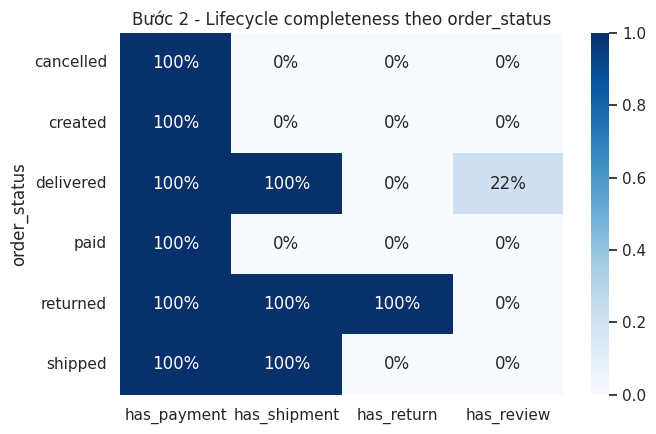

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(lifecycle.astype(float), annot=True, fmt=".0%", cmap="Blues", ax=ax)
ax.set_title("Bước 2 - Lifecycle completeness theo order_status")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Kiểm tra logic chéo giữa trạng thái đơn và sự tồn tại của payment, shipment, return, review. Cell này phát hiện các mâu thuẫn nghiệp vụ khó thấy bằng missing đơn lẻ.


In [35]:
cross_rules = pd.DataFrame([
    rule_result("cancelled order has shipment", len(order_flags), (order_flags.order_status == "cancelled") & order_flags.has_shipment, note="cancelled but shipped"),
    rule_result("returned status lacks return record", len(order_flags), (order_flags.order_status == "returned") & ~order_flags.has_return, note="returned status but no return record"),
    rule_result("delivered status lacks shipment", len(order_flags), (order_flags.order_status == "delivered") & ~order_flags.has_shipment, note="delivered but no shipment record"),
    rule_result("order lacks payment", len(order_flags), ~order_flags.has_payment, "MEDIUM", "missing payment"),
])
display(cross_rules)

,rule,checked_rows,issue_count,issue_pct,severity,note
0,cancelled order has shipment,646945,0,0.000,PASS,pass
1,returned status lacks return record,646945,80,0.012,HIGH,returned status but no return record
2,delivered status lacks shipment,646945,524,0.081,HIGH,delivered but no shipment record
3,order lacks payment,646945,0,0.000,PASS,pass


<!-- cell-note -->
**Mô tả cell:** Gom các issue từ FK, business rule, timeline và cross-field validation thành một issue log. Đây là bảng ưu tiên xử lý/rà soát chất lượng dữ liệu.


In [38]:
# check
issue_log = pd.concat([
    fk_summary.query("severity != 'PASS'").assign(source="foreign_key"),
    business_rules.query("severity != 'PASS'").assign(source="business_rule"),
    pd.DataFrame(timeline_rules).query("severity != 'PASS'").assign(source="timeline"),
    cross_rules.query("severity != 'PASS'").assign(source="cross_field"),
], ignore_index=True)
display(issue_log if len(issue_log) else pd.DataFrame({"status": ["No blocking issue found"]}))

,rule,checked_rows,issue_count,issue_pct,severity,note,source
0,signup_date <= order_date,646945,477453,73.801,HIGH,signup after order,timeline
1,returned status lacks return record,646945,80,0.012,HIGH,returned status but no return record,cross_field
2,delivered status lacks shipment,646945,524,0.081,HIGH,delivered but no shipment record,cross_field


<!-- cell-note -->
**Mô tả cell:** Tổng kết Bước 2 và ghi rõ những điểm cần lưu ý khi diễn giải. Note này phân biệt lỗi cần xử lý với missing hợp lệ theo nghiệp vụ.


In [39]:
show_note("Kết luận Bước 2", [
    "Data quality đủ để đi tiếp Revenue & Profit, nhưng các issue HIGH cần được ghi chú khi diễn giải kết quả.",
    "Missing promotion là hợp lý nghiệp vụ; missing ở khóa hoặc cột doanh thu nếu có là lỗi nghiêm trọng.",
    "Outlier tiền/discount/refund chỉ nên flag, không xóa tự động vì có thể là đơn lớn hoặc campaign thật.",
    "Timeline/lifecycle checks giúp tránh kết luận sai về vận hành, return và shipment.",
])

**Kết luận Bước 2**
- Data quality đủ để đi tiếp Revenue & Profit, nhưng các issue HIGH cần được ghi chú khi diễn giải kết quả.
- Missing promotion là hợp lý nghiệp vụ; missing ở khóa hoặc cột doanh thu nếu có là lỗi nghiêm trọng.
- Outlier tiền/discount/refund chỉ nên flag, không xóa tự động vì có thể là đơn lớn hoặc campaign thật.
- Timeline/lifecycle checks giúp tránh kết luận sai về vận hành, return và shipment.

## Bước 3 — Chuẩn bị bảng Revenue & Profit

Tạo hai bảng phân tích: `items` ở cấp order-item để phân tích product/category, và `orders` ở cấp order để phân tích trend/channel/AOV/customer. Các bảng phụ payment, return, shipment, review được aggregate trước khi join.

<!-- cell-note -->
**Mô tả cell:** Tạo bảng `items` ở cấp order-item bằng cách join item với order, product và return. Đây là bảng nền cho phân tích product/category và tính revenue/profit chi tiết.


In [36]:
items = tables["order_items"].merge(tables["orders"], on="order_id", how="left", validate="many_to_one")
items = items.merge(tables["products"][["product_id", "product_name", "category", "segment", "size", "color", "cogs"]], on="product_id", how="left", validate="many_to_one")
returns_by_item = tables["returns"].groupby(["order_id", "product_id"], as_index=False).agg(return_quantity=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
items = items.merge(returns_by_item, on=["order_id", "product_id"], how="left")
items[["return_quantity", "refund_amount"]] = items[["return_quantity", "refund_amount"]].fillna(0)
display(items.head())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,...,device_type,order_source,product_name,category,segment,size,color,cogs,return_quantity,refund_amount
0,1,2400,7,1138.22,0.0,NaN,NaN,2012-07-04,58578,1109,...,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,1053.798008,0.0,0.00
1,2,609,7,10166.25,0.0,NaN,NaN,2012-07-04,58621,1330,...,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,8987.704231,6.0,52458.01
2,3,396,3,11220.33,0.0,NaN,NaN,2012-07-04,58811,1473,...,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,10091.012256,0.0,0.00
3,4,635,5,10639.25,0.0,NaN,NaN,2012-07-04,59453,2360,...,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,9205.430478,0.0,0.00
4,6,1935,1,1597.84,0.0,NaN,NaN,2012-07-06,57821,2886,...,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1048.696357,0.0,0.00


<!-- cell-note -->
**Mô tả cell:** Tính các chỉ số tài chính ở cấp item như gross revenue, net revenue, cost, profit và margin. Cell này định nghĩa công thức chuẩn cho các phân tích sau.


In [37]:
items["gross_revenue"] = items.quantity * items.unit_price
items["discount_amount"] = items.discount_amount.fillna(0)
items["net_revenue"] = items.gross_revenue - items.discount_amount - items.refund_amount
items["cost"] = items.quantity * items.cogs.fillna(0)
items["profit"] = items.net_revenue - items.cost
items["margin_rate"] = safe_div(items.profit, items.net_revenue)
items["discount_rate"] = safe_div(items.discount_amount, items.gross_revenue)
items["is_returned"] = items.return_quantity > 0
items["month"] = month_start(items.order_date)
items["week"] = week_start(items.order_date)

<!-- cell-note -->
**Mô tả cell:** Aggregate item-level lên bảng `orders` ở cấp đơn hàng. Bảng này dùng để phân tích AOV, channel, customer, status và trend mà không bị nhân dòng.


In [38]:
orders = items.groupby("order_id", as_index=False).agg(
    order_date=("order_date", "first"), month=("month", "first"), week=("week", "first"), customer_id=("customer_id", "first"),
    order_status=("order_status", "first"), order_source=("order_source", "first"), payment_method=("payment_method", "first"),
    gross_revenue=("gross_revenue", "sum"), discount_amount=("discount_amount", "sum"), refund_amount=("refund_amount", "sum"),
    net_revenue=("net_revenue", "sum"), cost=("cost", "sum"), profit=("profit", "sum"), items=("product_id", "count"), units=("quantity", "sum"), returned_units=("return_quantity", "sum"),
)
orders["aov"] = orders.net_revenue
orders["margin_rate"] = safe_div(orders.profit, orders.net_revenue)
orders["discount_rate"] = safe_div(orders.discount_amount, orders.gross_revenue)
orders["is_returned"] = orders.returned_units > 0
orders["has_discount"] = orders.discount_amount > 0
display(orders.head())

,order_id,order_date,month,week,customer_id,order_status,order_source,payment_method,gross_revenue,discount_amount,...,cost,profit,items,units,returned_units,aov,margin_rate,discount_rate,is_returned,has_discount
0,1,2012-07-04,2012-07-01,2012-07-02,58578,delivered,paid_search,credit_card,7967.54,0.0,...,7376.586059,590.953941,1,7,0.0,7967.54,0.074170,0.0,False,False
1,2,2012-07-04,2012-07-01,2012-07-02,58621,returned,paid_search,cod,71163.75,0.0,...,62913.929616,-44208.189616,1,7,6.0,18705.74,-2.363349,0.0,True,False
2,3,2012-07-04,2012-07-01,2012-07-02,58811,delivered,direct,credit_card,33660.99,0.0,...,30273.036767,3387.953233,1,3,0.0,33660.99,0.100649,0.0,False,False
3,4,2012-07-04,2012-07-01,2012-07-02,59453,delivered,referral,credit_card,53196.25,0.0,...,46027.152390,7169.097610,1,5,0.0,53196.25,0.134767,0.0,False,False
4,6,2012-07-06,2012-07-01,2012-07-02,57821,delivered,email_campaign,paypal,1597.84,0.0,...,1048.696357,549.143643,1,1,0.0,1597.84,0.343679,0.0,False,False


<!-- cell-note -->
**Mô tả cell:** Bổ sung payment, shipment, return và review đã aggregate vào bảng order-level. Cell này làm giàu dữ liệu đơn hàng bằng các thông tin vận hành và phản hồi khách.


In [39]:
payment_agg = tables["payments"].groupby("order_id", as_index=False).agg(payment_value=("payment_value", "sum"), installments=("installments", "max"))
ship_agg = tables["shipments"].assign(delivery_days=lambda d: (d.delivery_date - d.ship_date).dt.days)[["order_id", "ship_date", "delivery_date", "delivery_days"]]
review_agg = tables["reviews"].groupby("order_id", as_index=False).agg(avg_rating=("rating", "mean"), review_count=("review_id", "nunique"))
orders = orders.merge(payment_agg, on="order_id", how="left").merge(ship_agg, on="order_id", how="left").merge(review_agg, on="order_id", how="left")
print(f"items rows: {len(items):,} | orders rows: {len(orders):,}")

items rows: 714,669 | orders rows: 646,945


<!-- cell-note -->
**Mô tả cell:** Kiểm tra lại các công thức tài chính và hiển thị tổng gross, net, profit, margin. Đây là sanity check trước khi bước vào các module phân tích.


In [40]:
formula_check = pd.DataFrame([
    ["gross_revenue", "quantity * unit_price", items.gross_revenue.sum()],
    ["net_revenue", "gross - discount - refund", items.net_revenue.sum()],
    ["profit", "net_revenue - cost", items.profit.sum()],
    ["margin_rate", "profit / net_revenue", orders.profit.sum() / orders.net_revenue.sum()],
    ["AOV", "net_revenue / total_orders", orders.net_revenue.sum() / orders.order_id.nunique()],
], columns=["metric", "formula", "value"])
display(formula_check)

,metric,formula,value
0,gross_revenue,quantity * unit_price,1.643048e+10
1,net_revenue,gross - discount - refund,1.517021e+10
2,profit,net_revenue - cost,1.006758e+09
3,margin_rate,profit / net_revenue,6.636418e-02
4,AOV,net_revenue / total_orders,2.344899e+04


### 3.3.1 — Revenue Overview

Mục tiêu: nhìn toàn cảnh quy mô kinh doanh, so sánh gross/net/profit, kiểm tra AOV và độ lệch của giá trị đơn hàng.

<!-- cell-note -->
**Mô tả cell:** Tạo bảng KPI tổng quan cho doanh thu, lợi nhuận, số đơn, số khách, AOV và margin. Đây là màn hình số lớn để nắm quy mô kinh doanh.


In [41]:
kpi = pd.DataFrame({"metric": ["Gross Revenue", "Net Revenue", "Profit", "Orders", "Customers", "Items Sold", "AOV", "Median Order Value", "Revenue/Customer", "Margin Rate"], "value": [orders.gross_revenue.sum(), orders.net_revenue.sum(), orders.profit.sum(), orders.order_id.nunique(), orders.customer_id.nunique(), orders.units.sum(), orders.net_revenue.mean(), orders.net_revenue.median(), orders.net_revenue.sum()/orders.customer_id.nunique(), orders.profit.sum()/orders.net_revenue.sum()]})
display(kpi)

,metric,value
0,Gross Revenue,1.643048e+10
1,Net Revenue,1.517021e+10
2,Profit,1.006758e+09
3,Orders,6.469450e+05
4,Customers,9.024600e+04
5,Items Sold,3.213143e+06
6,AOV,2.344899e+04
7,Median Order Value,1.635867e+04
8,Revenue/Customer,1.680984e+05
9,Margin Rate,6.636418e-02


<!-- cell-note -->
**Mô tả cell:** So sánh Gross Revenue, Net Revenue và Profit bằng biểu đồ. Cell này cho thấy doanh thu bị giảm như thế nào sau discount/refund/cost.


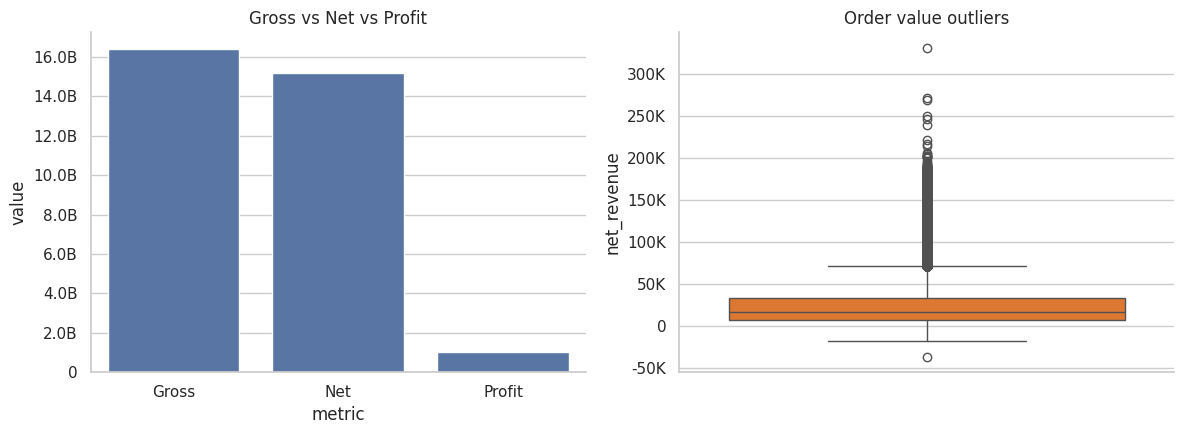

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=pd.DataFrame({"metric": ["Gross", "Net", "Profit"], "value": [orders.gross_revenue.sum(), orders.net_revenue.sum(), orders.profit.sum()]}), x="metric", y="value", ax=axes[0])
axes[0].set_title("Gross vs Net vs Profit"); axes[0].yaxis.set_major_formatter(money)
sns.boxplot(y=orders.net_revenue, ax=axes[1], color="#f97316")
axes[1].set_title("Order value outliers"); axes[1].yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ phân phối net revenue theo đơn và phiên bản log-scale. Mục tiêu là kiểm tra độ lệch của giá trị đơn hàng và tác động của outlier.


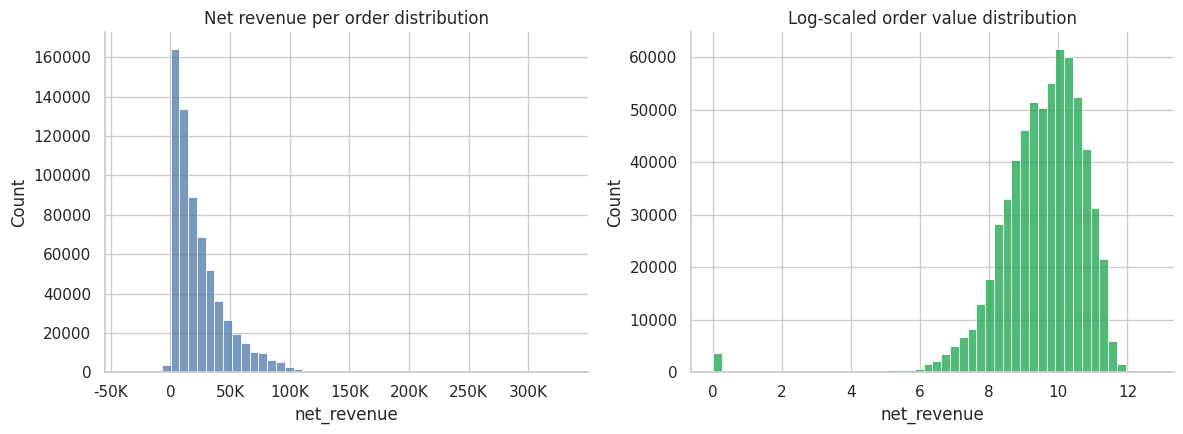

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(orders.net_revenue, bins=50, ax=axes[0], color="#4c78a8")
axes[0].set_title("Net revenue per order distribution"); axes[0].xaxis.set_major_formatter(money)
sns.histplot(np.log1p(orders.net_revenue.clip(lower=0)), bins=50, ax=axes[1], color="#16a34a")
axes[1].set_title("Log-scaled order value distribution")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Chia đơn hàng thành 5 phân khúc theo net revenue và tổng hợp KPI từng nhóm. Cell này giúp hiểu nhóm đơn giá trị cao/thấp đóng góp ra sao.


In [45]:
# 1. Phân khúc đơn hàng thành 5 nhóm bằng nhau dựa trên Net Revenue
order_value_segments = pd.qcut(orders.net_revenue.rank(method="first"), q=5, labels=["very_low", "low", "mid", "high", "very_high"])

# 2. Gom nhóm tính tổng các chỉ số tuyệt đối (Bỏ không tính mean của margin_rate ở đây)
segment_summary = (
    orders.assign(value_segment=order_value_segments)
    .groupby("value_segment", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_revenue", "sum"),
        aov=("net_revenue", "mean"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# 3. Tính chuẩn Biên lợi nhuận (Margin Rate) thực tế cho từng phân khúc
segment_summary["margin_rate"] = segment_summary["profit"] / segment_summary["revenue"]

# 4. Hiển thị kết quả
display(segment_summary)

,value_segment,orders,revenue,aov,profit,margin_rate
0,very_low,129389,4.102850e+08,3170.942262,-1.920421e+08,-0.468070
1,low,129389,1.119426e+09,8651.632403,-1.607101e+07,-0.014356
2,mid,129389,2.137804e+09,16522.302298,2.776009e+07,0.012985
3,high,129389,3.748218e+09,28968.602007,2.804322e+08,0.074817
4,very_high,129389,7.754475e+09,59931.487340,9.066793e+08,0.116923


<!-- cell-note -->
**Mô tả cell:** Tổng kết Revenue Overview bằng các chỉ số quan trọng và lưu ý về AOV/median. Note này giúp tránh kết luận sai khi phân phối đơn hàng bị lệch.


In [46]:
show_note("Kết luận 3.3.1", [
    f"Net revenue đạt {orders.net_revenue.sum():,.0f} từ {orders.order_id.nunique():,} đơn và {orders.customer_id.nunique():,} khách.",
    f"AOV trung bình {orders.net_revenue.mean():,.0f}, median {orders.net_revenue.median():,.0f}; median cần đi kèm AOV vì phân phối đơn có đuôi dài.",
    "Gross-Net-Profit bridge cho thấy discount/refund/cost bào mòn dòng tiền ở mức nào.",
])

**Kết luận 3.3.1**
- Net revenue đạt 15,170,208,946 từ 646,945 đơn và 90,246 khách.
- AOV trung bình 23,449, median 16,359; median cần đi kèm AOV vì phân phối đơn có đuôi dài.
- Gross-Net-Profit bridge cho thấy discount/refund/cost bào mòn dòng tiền ở mức nào.

### 3.3.2 — Revenue Trend

Mục tiêu: xem doanh thu biến động theo thời gian, có mùa vụ không, tháng nào bất thường, và biến động đến từ volume hay AOV.

<!-- cell-note -->
**Mô tả cell:** Tổng hợp doanh thu, profit, số đơn, số khách và AOV theo ngày, tuần, tháng. Đây là bảng nền cho toàn bộ phân tích trend.


In [47]:
daily = orders.groupby("order_date", as_index=False).agg(revenue=("net_revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"), customers=("customer_id", "nunique"), aov=("net_revenue", "mean"))
weekly = orders.groupby("week", as_index=False).agg(revenue=("net_revenue", "sum"), orders=("order_id", "nunique"), aov=("net_revenue", "mean"))
monthly = orders.groupby("month", as_index=False).agg(revenue=("net_revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"), customers=("customer_id", "nunique"), aov=("net_revenue", "mean"))
monthly["revenue_growth_pct"] = monthly.revenue.pct_change()
monthly["orders_growth_pct"] = monthly.orders.pct_change()
monthly["aov_growth_pct"] = monthly.aov.pct_change()
display(monthly.tail(18))

,month,revenue,profit,orders,customers,aov,revenue_growth_pct,orders_growth_pct,aov_growth_pct
108,2021-07-01,8.812942e+07,-6.331191e+06,3292,3126,26770.782934,-0.261850,-0.169316,-0.111394
109,2021-08-01,6.569128e+07,-2.995964e+07,3225,3068,20369.389076,-0.254604,-0.020352,-0.239119
110,2021-09-01,6.576503e+07,-5.129268e+06,2431,2320,27052.667038,0.001123,-0.246202,0.328104
111,2021-10-01,6.309775e+07,8.103644e+06,1831,1754,34460.811191,-0.040558,-0.246812,0.273842
112,2021-11-01,4.525839e+07,-4.073110e+05,1630,1541,27765.885669,-0.282726,-0.109776,-0.194276
113,2021-12-01,3.893465e+07,-1.251325e+07,2186,2060,17810.911528,-0.139725,0.341104,-0.358533
114,2022-01-01,5.706222e+07,6.210765e+06,1719,1627,33195.011454,0.465590,-0.213632,0.863746
115,2022-02-01,7.688333e+07,1.159775e+07,2182,2072,35235.254780,0.347359,0.269343,0.061462
116,2022-03-01,1.257497e+08,4.082709e+06,4231,3965,29721.030378,0.635591,0.939047,-0.156497
117,2022-04-01,1.291596e+08,4.798011e+06,4489,4196,28772.475097,0.027117,0.060978,-0.031915


<!-- cell-note -->
**Mô tả cell:** Vẽ daily revenue cùng rolling average 30 ngày. Biểu đồ này làm mượt nhiễu ngày và giúp nhìn xu hướng dài hơn.


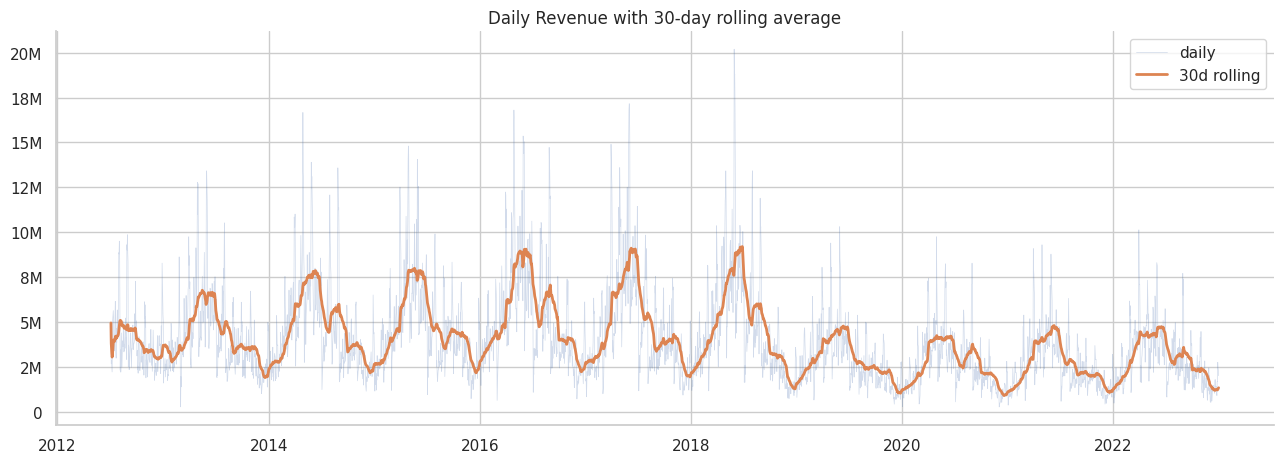

In [48]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(daily.order_date, daily.revenue, alpha=.25, linewidth=.5, label="daily")
ax.plot(daily.order_date, daily.revenue.rolling(30, min_periods=1).mean(), linewidth=2, label="30d rolling")
ax.set_title("Daily Revenue with 30-day rolling average")
ax.yaxis.set_major_formatter(money); ax.legend(); plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ monthly revenue, order count và AOV trên ba biểu đồ cùng trục thời gian. Cell này tách biến động doanh thu thành volume và giá trị đơn.


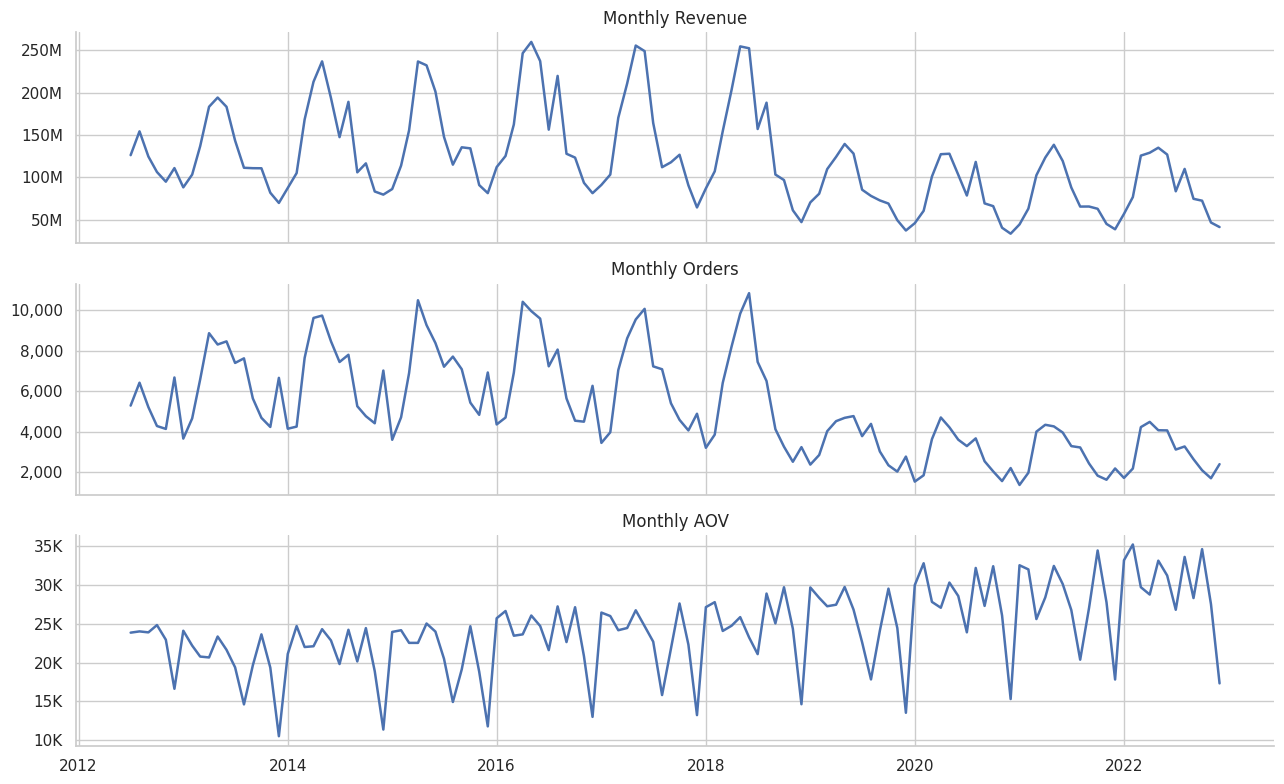

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, y, title, fmt in zip(axes, ["revenue", "orders", "aov"], ["Monthly Revenue", "Monthly Orders", "Monthly AOV"], [money, count_axis, money]):
    ax.plot(monthly.month, monthly[y], linewidth=1.8)
    ax.set_title(title); ax.yaxis.set_major_formatter(fmt)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ tăng trưởng doanh thu MoM theo tháng. Màu xanh/đỏ giúp nhận diện nhanh tháng tăng trưởng và tháng sụt giảm.


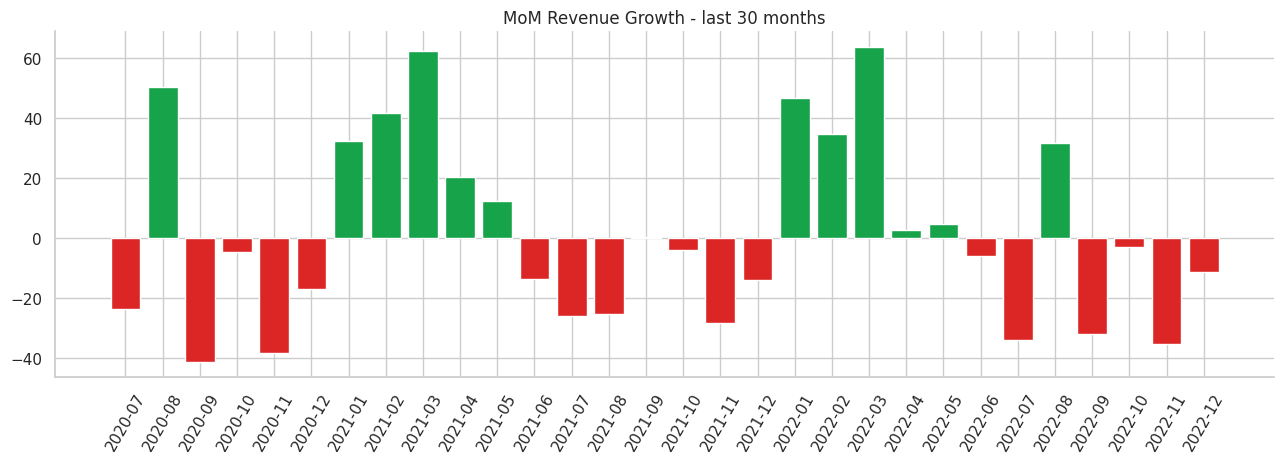

In [50]:
growth_view = monthly.dropna(subset=["revenue_growth_pct"]).assign(month_label=lambda d: d.month.dt.strftime("%Y-%m"))
fig, ax = plt.subplots(figsize=(13, 4.8))
colors = np.where(growth_view.revenue_growth_pct >= 0, "#16a34a", "#dc2626")
ax.bar(growth_view.month_label.tail(30), growth_view.revenue_growth_pct.tail(30) * 100, color=colors[-30:])
ax.set_title("MoM Revenue Growth - last 30 months")
ax.tick_params(axis="x", rotation=60); plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Liệt kê các tháng cực trị: revenue cao nhất, tăng mạnh nhất và giảm mạnh nhất. Bảng này phục vụ phần diễn giải nguyên nhân biến động.


In [51]:
trend_extremes = pd.concat([
    monthly.nlargest(5, "revenue").assign(type="top_revenue_month"),
    monthly.dropna(subset=["revenue_growth_pct"]).nsmallest(5, "revenue_growth_pct").assign(type="worst_growth_month"),
    monthly.dropna(subset=["revenue_growth_pct"]).nlargest(5, "revenue_growth_pct").assign(type="best_growth_month"),
])
display(trend_extremes[["type", "month", "revenue", "orders", "aov", "revenue_growth_pct", "orders_growth_pct", "aov_growth_pct"]])

,type,month,revenue,orders,aov,revenue_growth_pct,orders_growth_pct,aov_growth_pct
46,top_revenue_month,2016-05-01,2.597584e+08,9965,26067.077387,0.054072,-0.044216,0.102835
58,top_revenue_month,2017-05-01,2.554746e+08,9553,26742.863339,0.212030,0.108365,0.093529
70,top_revenue_month,2018-05-01,2.545053e+08,9841,25861.736223,0.250811,0.197202,0.044779
71,top_revenue_month,2018-06-01,2.522785e+08,10851,23249.329039,-0.008750,0.102632,-0.101014
59,top_revenue_month,2017-06-01,2.488959e+08,10078,24696.957419,-0.025751,0.054957,-0.076503
74,worst_growth_month,2018-09-01,1.034475e+08,4129,25053.879685,-0.450139,-0.365745,-0.133060
26,worst_growth_month,2014-09-01,1.060537e+08,5264,20146.972112,-0.439266,-0.325733,-0.168379
50,worst_growth_month,2016-09-01,1.279363e+08,5650,22643.595618,-0.417713,-0.299442,-0.168824
98,worst_growth_month,2020-09-01,6.944561e+07,2543,27308.535486,-0.413074,-0.307839,-0.152038
100,worst_growth_month,2020-11-01,4.076520e+07,1563,26081.380083,-0.384346,-0.234574,-0.195671


<!-- cell-note -->
**Mô tả cell:** Tổng kết Revenue Trend bằng các mốc tháng đáng chú ý. Note này nhắc người đọc kiểm tra doanh thu biến động do volume hay AOV.


In [52]:
show_note("Kết luận 3.3.2", [
    f"Tháng revenue cao nhất là {monthly.loc[monthly.revenue.idxmax(), 'month']:%Y-%m}.",
    f"Tháng giảm MoM mạnh nhất là {monthly.dropna(subset=['revenue_growth_pct']).loc[monthly.dropna(subset=['revenue_growth_pct']).revenue_growth_pct.idxmin(), 'month']:%Y-%m}.",
    "Cần đọc revenue cùng orders và AOV để biết giảm do volume, do giá trị đơn hàng, hay cả hai.",
])

**Kết luận 3.3.2**
- Tháng revenue cao nhất là 2016-05.
- Tháng giảm MoM mạnh nhất là 2018-09.
- Cần đọc revenue cùng orders và AOV để biết giảm do volume, do giá trị đơn hàng, hay cả hai.

### 3.3.3 — Revenue by Product/Category

Mục tiêu: xác định category/product đóng góp doanh thu, nhóm bán nhiều nhưng doanh thu thấp, nhóm bán ít nhưng doanh thu cao, và mức độ phụ thuộc vào category top.

<!-- cell-note -->
**Mô tả cell:** Định nghĩa hàm tổng hợp theo nhóm và tạo bảng category/product/segment. Cell này chuẩn hóa KPI cho phân tích product và danh mục.


In [53]:
def summarize(df, group_cols):
    return df.groupby(group_cols, as_index=False).agg(revenue=("net_revenue", "sum"), gross_revenue=("gross_revenue", "sum"), profit=("profit", "sum"), units=("quantity", "sum"), orders=("order_id", "nunique"), refund=("refund_amount", "sum"), discount=("discount_amount", "sum")).assign(aov=lambda d: d.revenue / d.orders, margin_rate=lambda d: d.profit / d.revenue, revenue_share_pct=lambda d: d.revenue / d.revenue.sum())
category = summarize(items, ["category"]).sort_values("revenue", ascending=False)
product = summarize(items, ["product_name", "category"]).sort_values("revenue", ascending=False)
display(category)

,category,revenue,gross_revenue,profit,units,orders,refund,discount,aov,margin_rate,revenue_share_pct
3,Streetwear,1.215171e+10,1.313135e+10,7.590416e+08,1768826,389543,4.067659e+08,5.728693e+08,31194.787633,0.062464,0.801025
2,Outdoor,2.274679e+09,2.494883e+09,1.883166e+08,1170000,200454,7.871751e+07,1.414860e+08,11347.637273,0.082788,0.149944
0,Casual,4.262581e+08,4.606484e+08,1.971367e+07,107469,23600,1.402709e+07,2.036319e+07,18061.783872,0.046248,0.028098
1,GenZ,3.175604e+08,3.435991e+08,3.968661e+07,166848,37054,1.114977e+07,1.488892e+07,8570.205792,0.124973,0.020933


<!-- cell-note -->
**Mô tả cell:** Vẽ revenue và revenue share theo category. Mục tiêu là thấy danh mục nào đang gánh phần lớn doanh thu.


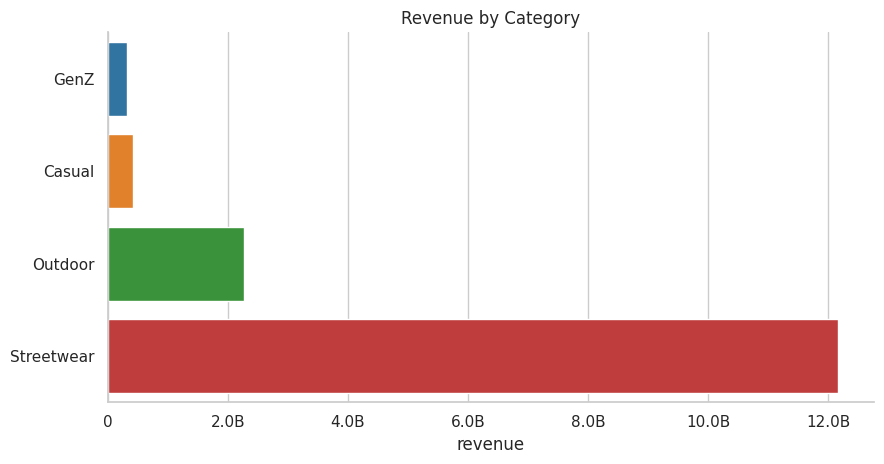

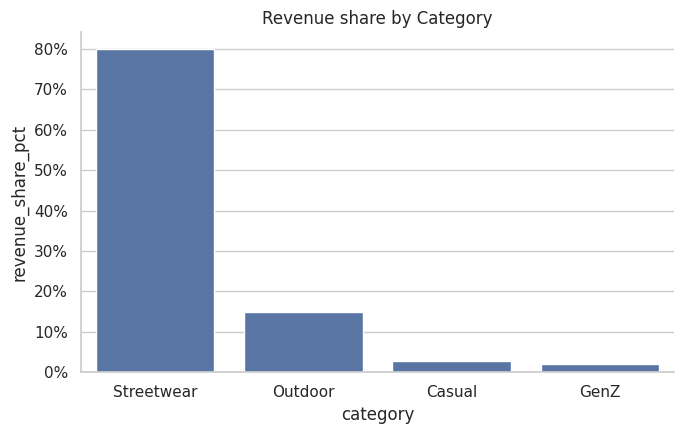

In [55]:
barh(category, "revenue", "category", "Revenue by Category")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=category, x="category", y="revenue_share_pct", ax=ax)
ax.set_title("Revenue share by Category"); ax.yaxis.set_major_formatter(pct_axis)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Hiển thị top product theo revenue và vẽ top 15 sản phẩm. Cell này nhận diện các SKU chiến lược cần theo dõi.


,product_name,category,revenue,gross_revenue,profit,units,orders,refund,discount,aov,margin_rate,revenue_share_pct
1005,SaigonFlex UM-92,Streetwear,3.682268e+08,3.982136e+08,1.255739e+06,33277,7418,12241878.26,17744843.04,49639.638198,0.003410,0.024273
288,HanoiStreet UM-10,Streetwear,3.166296e+08,3.422650e+08,-3.400837e+07,28993,6422,10879460.50,14755886.24,49303.899246,-0.107407,0.020872
969,SaigonFlex UM-43,Streetwear,3.153600e+08,3.407063e+08,1.051106e+08,31471,7053,9654909.83,15691385.26,44712.883567,0.333303,0.020788
928,SaigonFlex UM-01,Streetwear,2.879669e+08,3.114886e+08,-2.432715e+07,30088,6690,10133931.30,13387742.65,43044.382534,-0.084479,0.018982
995,SaigonFlex UM-80,Streetwear,2.485935e+08,2.673875e+08,2.057560e+07,22709,4982,7958581.64,10835387.00,49898.337334,0.082768,0.016387
1009,SaigonFlex UM-96,Streetwear,2.338790e+08,2.518164e+08,-2.338672e+07,24485,5444,7121041.39,10816311.18,42960.882430,-0.099995,0.015417
881,SaigonFlex UC-69,Streetwear,1.928832e+08,2.079307e+08,4.164022e+07,36515,8115,6113477.47,8934009.41,23768.720154,0.215883,0.012715
938,SaigonFlex UM-11,Streetwear,1.908530e+08,2.057155e+08,-1.788406e+07,14419,3229,5432011.43,9430508.72,59105.916333,-0.093706,0.012581
1095,UrbanVN UE-05,Streetwear,1.717334e+08,1.850812e+08,6.433148e+07,35844,7924,5302854.38,8044983.75,21672.563997,0.374601,0.011320
976,SaigonFlex UM-54,Streetwear,1.701689e+08,1.852522e+08,-1.020554e+07,15992,3593,5672410.38,9410881.09,47361.221339,-0.059973,0.011217


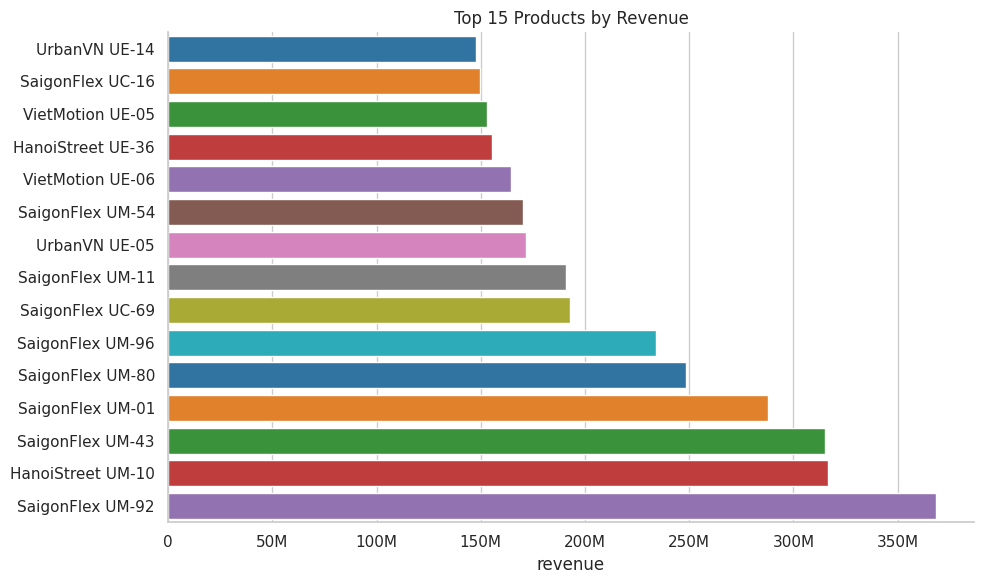

In [58]:
display(product.head(20))
barh(product.head(15), "revenue", "product_name", "Top 15 Products by Revenue", figsize=(10, 6))

<!-- cell-note -->
**Mô tả cell:** Vẽ scatter units sold vs revenue theo product. Biểu đồ giúp phân biệt sản phẩm bán nhiều, sản phẩm giá trị cao và nhóm nằm giữa.


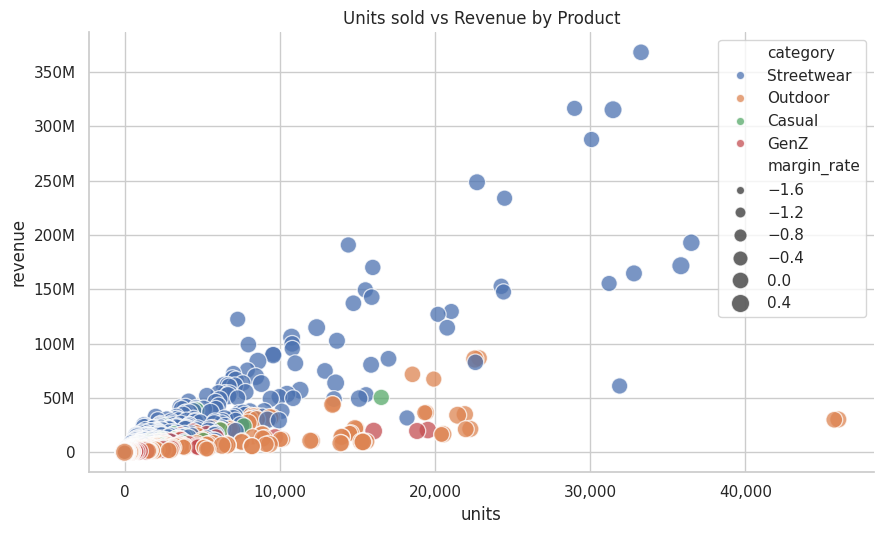

In [59]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=product, x="units", y="revenue", hue="category", size="margin_rate", sizes=(20, 180), alpha=.75, ax=ax)
ax.set_title("Units sold vs Revenue by Product")
ax.xaxis.set_major_formatter(count_axis); ax.yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Phân nhóm product theo ma trận units/revenue cao-thấp. Cell này tạo góc nhìn hành động cho product portfolio.


In [60]:
product_quadrant = product.copy()
product_quadrant["unit_group"] = np.where(product_quadrant.units >= product_quadrant.units.median(), "high_units", "low_units")
product_quadrant["revenue_group"] = np.where(product_quadrant.revenue >= product_quadrant.revenue.median(), "high_revenue", "low_revenue")
quadrant_summary = product_quadrant.groupby(["unit_group", "revenue_group"]).agg(products=("product_name", "count"), revenue=("revenue", "sum"), avg_margin=("margin_rate", "mean")).reset_index()
display(quadrant_summary)

,unit_group,revenue_group,products,revenue,avg_margin
0,high_units,high_revenue,654,1.448572e+10,0.083524
1,high_units,low_revenue,67,9.753739e+07,0.070439
2,low_units,high_revenue,66,2.129145e+08,0.075705
3,low_units,low_revenue,653,3.740339e+08,0.073700


<!-- cell-note -->
**Mô tả cell:** Tổng kết Revenue by Product/Category. Note này nhấn mạnh category top, sản phẩm chiến lược và rủi ro tập trung.


In [61]:
show_note("Kết luận 3.3.3", [
    f"Category lớn nhất là {category.iloc[0].category}, đóng góp {category.iloc[0].revenue_share_pct:.1%} revenue.",
    "Top product chart cho thấy sản phẩm chiến lược; scatter units-revenue giúp tách sản phẩm premium và sản phẩm kéo volume.",
    "Nếu một category chiếm tỷ trọng quá lớn, cần quản trị rủi ro phụ thuộc tồn kho, chất lượng và return.",
])

**Kết luận 3.3.3**
- Category lớn nhất là Streetwear, đóng góp 80.1% revenue.
- Top product chart cho thấy sản phẩm chiến lược; scatter units-revenue giúp tách sản phẩm premium và sản phẩm kéo volume.
- Nếu một category chiếm tỷ trọng quá lớn, cần quản trị rủi ro phụ thuộc tồn kho, chất lượng và return.

### 3.3.4 — Revenue by Channel/Source

Mục tiêu: kênh nào tạo doanh thu cao nhất, kênh nào có AOV tốt, kênh nào tăng trưởng tốt và nên ưu tiên ngân sách vào đâu.

<!-- cell-note -->
**Mô tả cell:** Tổng hợp revenue, profit, orders, customers, AOV và margin theo order source. Đây là bảng chính để đánh giá hiệu quả kênh bán.


In [62]:
channel = orders.groupby("order_source", as_index=False).agg(revenue=("net_revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"), customers=("customer_id", "nunique"), aov=("net_revenue", "mean"), margin_rate=("margin_rate", "mean")).assign(revenue_share_pct=lambda d: d.revenue / d.revenue.sum()).sort_values("revenue", ascending=False)
display(channel)

,order_source,revenue,profit,orders,customers,aov,margin_rate,revenue_share_pct
2,organic_search,4.241008e+09,2.805956e+08,181495,60692,23367.079041,-0.354243,0.279562
3,paid_search,3.331177e+09,2.211577e+08,141652,54453,23516.625865,-0.263192,0.219587
5,social_media,3.040768e+09,2.044312e+08,129710,52451,23442.816773,-1.611699,0.200443
1,email_campaign,1.819270e+09,1.211040e+08,77572,40530,23452.668682,-0.061954,0.119924
4,referral,1.514908e+09,9.799141e+07,64565,36480,23463.293127,0.815894,0.099861
0,direct,1.223078e+09,8.147843e+07,51951,31880,23542.918303,-0.522316,0.080624


<!-- cell-note -->
**Mô tả cell:** So sánh channel theo revenue, số đơn và AOV. Cell này giúp tách kênh tạo volume khỏi kênh tạo đơn giá trị cao.


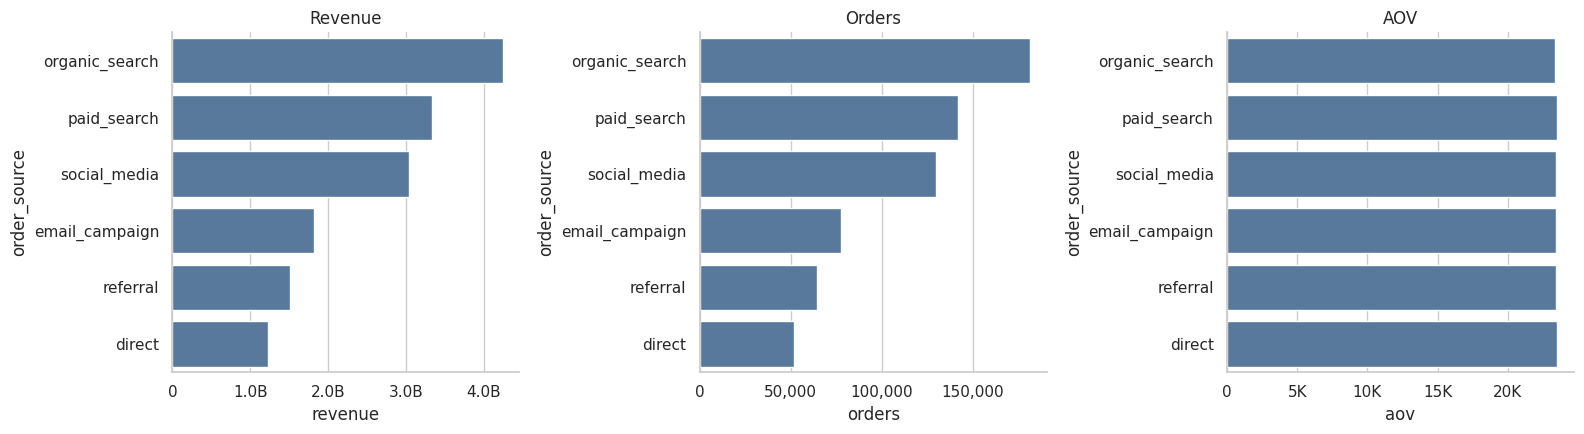

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, y, title, fmt in zip(axes, ["revenue", "orders", "aov"], ["Revenue", "Orders", "AOV"], [money, count_axis, money]):
    sns.barplot(data=channel, x=y, y="order_source", ax=ax, color="#4c78a8")
    ax.set_title(title); ax.xaxis.set_major_formatter(fmt)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Tạo bảng revenue theo tháng và kênh bán. Dữ liệu pivot này dùng để xem dịch chuyển channel mix theo thời gian.


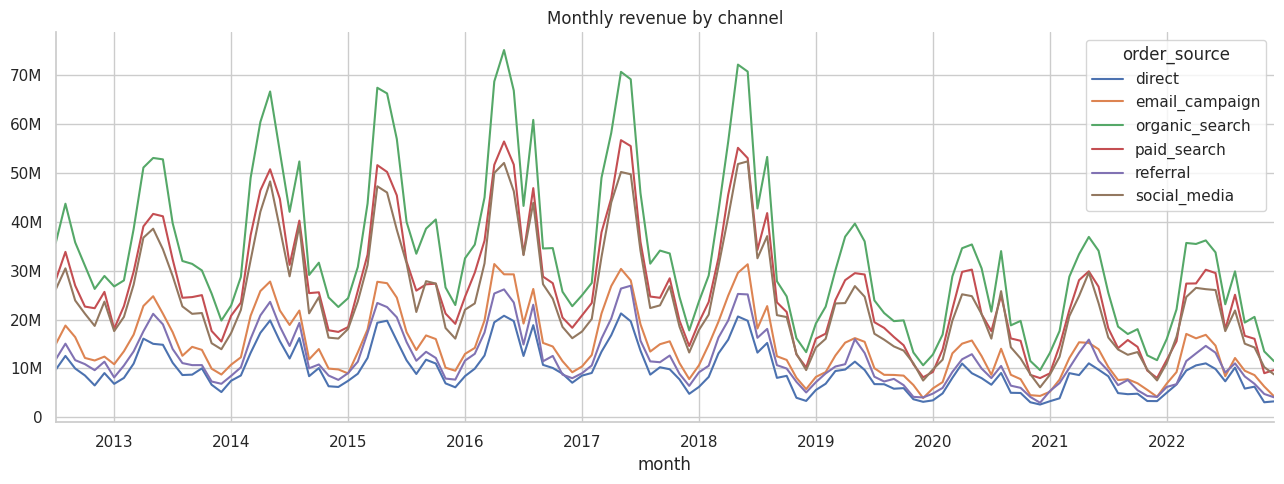

In [64]:
channel_month = orders.groupby(["month", "order_source"], as_index=False).agg(revenue=("net_revenue", "sum"), orders=("order_id", "nunique"), aov=("net_revenue", "mean"))
pivot_channel = channel_month.pivot(index="month", columns="order_source", values="revenue").fillna(0)
fig, ax = plt.subplots(figsize=(13, 5))
pivot_channel.plot(ax=ax, linewidth=1.5)
ax.set_title("Monthly revenue by channel"); ax.yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ stacked area chart cho channel revenue mix. Biểu đồ cho biết tỷ trọng các kênh có thay đổi qua thời gian hay không.


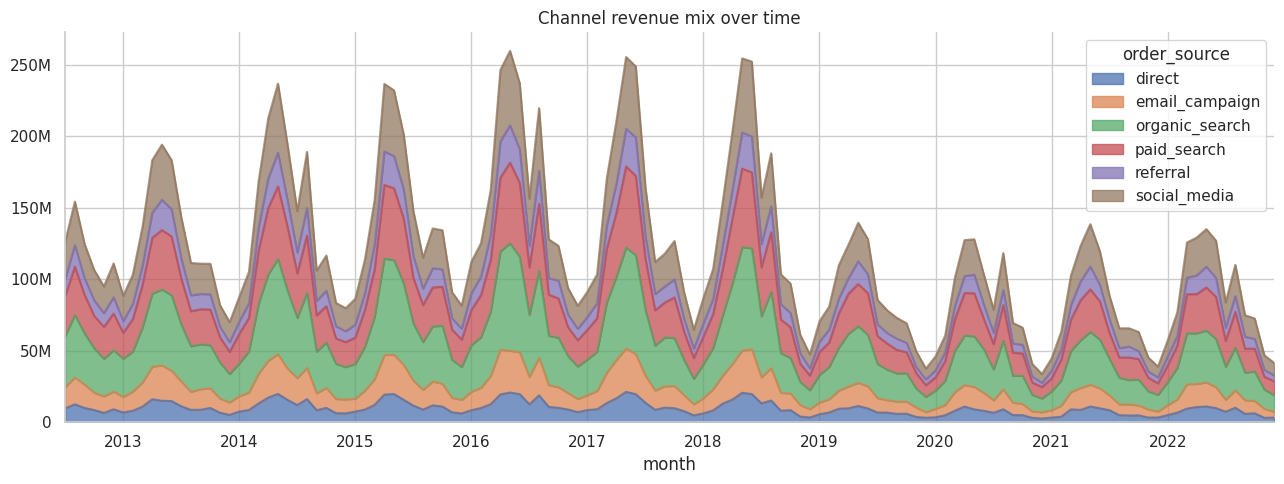

In [65]:
fig, ax = plt.subplots(figsize=(13, 5))
pivot_channel.plot.area(ax=ax, alpha=.75)
ax.set_title("Channel revenue mix over time"); ax.yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Tính tăng trưởng gần đây theo từng kênh. Cell này giúp bổ sung góc nhìn momentum thay vì chỉ nhìn tổng revenue lịch sử.


In [66]:
channel_growth = channel_month.sort_values(["order_source", "month"]).assign(revenue_growth=lambda d: d.groupby("order_source").revenue.pct_change())
recent_growth = channel_growth.dropna().groupby("order_source", as_index=False).tail(6).groupby("order_source", as_index=False).agg(avg_recent_growth=("revenue_growth", "mean"), recent_revenue=("revenue", "mean"), recent_aov=("aov", "mean"))
display(recent_growth.sort_values("avg_recent_growth", ascending=False))

,order_source,avg_recent_growth,recent_revenue,recent_aov
0,direct,-0.113147,5.998540e+06,29147.027121
3,paid_search,-0.122761,1.575096e+07,28415.832645
2,organic_search,-0.134408,1.964085e+07,27538.572198
5,social_media,-0.145423,1.464166e+07,28444.206800
1,email_campaign,-0.146882,8.212416e+06,27015.434414
4,referral,-0.161938,7.375477e+06,28232.753513


<!-- cell-note -->
**Mô tả cell:** Tổng kết Revenue by Channel/Source. Note này nêu kênh revenue cao nhất, kênh AOV tốt nhất và gợi ý ưu tiên ngân sách.


In [67]:
show_note("Kết luận 3.3.4", [
    f"Kênh revenue cao nhất là {channel.iloc[0].order_source}; kênh AOV cao nhất là {channel.loc[channel.aov.idxmax()].order_source}.",
    "Stacked/line chart giúp xem mix kênh có dịch chuyển theo thời gian không.",
    "Kênh nhiều đơn phù hợp mục tiêu tăng volume; kênh AOV/margin cao phù hợp mục tiêu chất lượng doanh thu.",
])

**Kết luận 3.3.4**
- Kênh revenue cao nhất là organic_search; kênh AOV cao nhất là direct.
- Stacked/line chart giúp xem mix kênh có dịch chuyển theo thời gian không.
- Kênh nhiều đơn phù hợp mục tiêu tăng volume; kênh AOV/margin cao phù hợp mục tiêu chất lượng doanh thu.

### 3.3.5 — Profit & Margin

Mục tiêu: không chỉ nhìn revenue, mà xem revenue có chuyển hóa thành profit không. Phần này tìm category/product revenue cao nhưng margin thấp hoặc profit âm.

<!-- cell-note -->
**Mô tả cell:** Sắp xếp category theo profit và hiển thị revenue, profit, margin. Đây là bước chuyển từ nhìn doanh thu sang nhìn hiệu quả tài chính.


In [68]:
profit_category = category.sort_values("profit", ascending=False)
display(profit_category[["category", "revenue", "profit", "margin_rate", "units", "orders"]])

,category,revenue,profit,margin_rate,units,orders
3,Streetwear,1.215171e+10,7.590416e+08,0.062464,1768826,389543
2,Outdoor,2.274679e+09,1.883166e+08,0.082788,1170000,200454
1,GenZ,3.175604e+08,3.968661e+07,0.124973,166848,37054
0,Casual,4.262581e+08,1.971367e+07,0.046248,107469,23600


<!-- cell-note -->
**Mô tả cell:** Vẽ combo chart profit và margin theo category. Cell này giúp thấy danh mục nào doanh thu/lợi nhuận tốt nhưng margin thấp hoặc cao.


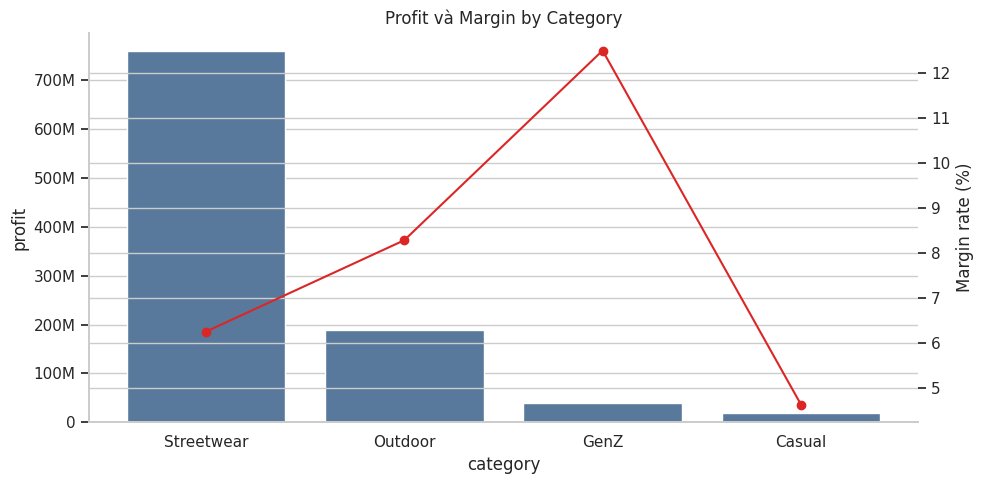

In [69]:
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=profit_category, x="category", y="profit", color="#4c78a8", ax=ax1)
ax1.set_title("Profit và Margin by Category"); ax1.yaxis.set_major_formatter(money)
ax2 = ax1.twinx(); ax2.plot(profit_category.category, profit_category.margin_rate * 100, color="#dc2626", marker="o")
ax2.set_ylabel("Margin rate (%)")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ scatter revenue vs margin theo product. Biểu đồ giúp nhận diện sản phẩm revenue cao-margin thấp, revenue thấp-margin cao và các điểm rủi ro.


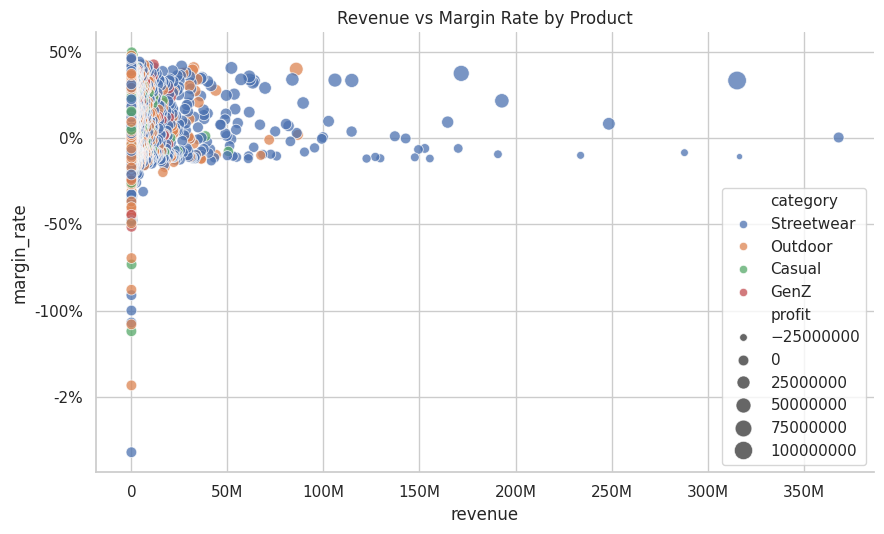

In [70]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=product, x="revenue", y="margin_rate", hue="category", size="profit", sizes=(20, 180), alpha=.75, ax=ax)
ax.set_title("Revenue vs Margin Rate by Product")
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(pct_axis)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Liệt kê top sản phẩm âm profit và top sản phẩm đóng góp profit cao. Bảng này phục vụ khuyến nghị tối ưu portfolio.


In [71]:
profit_risk = product.sort_values("profit").head(20)
profit_star = product.query("profit > 0").sort_values("profit", ascending=False).head(20)
display(profit_risk[["product_name", "category", "revenue", "profit", "margin_rate", "units"]])
display(profit_star[["product_name", "category", "revenue", "profit", "margin_rate", "units"]])

,product_name,category,revenue,profit,margin_rate,units
288,HanoiStreet UM-10,Streetwear,3.166296e+08,-3.400837e+07,-0.107407,28993
928,SaigonFlex UM-01,Streetwear,2.879669e+08,-2.432715e+07,-0.084479,30088
1009,SaigonFlex UM-96,Streetwear,2.338790e+08,-2.338672e+07,-0.099995,24485
279,HanoiStreet UE-36,Streetwear,1.554091e+08,-1.840349e+07,-0.118420,31220
938,SaigonFlex UM-11,Streetwear,1.908530e+08,-1.788406e+07,-0.093706,14419
1102,UrbanVN UE-14,Streetwear,1.475784e+08,-1.646227e+07,-0.111549,24418
1103,UrbanVN UE-15,Streetwear,1.296185e+08,-1.519300e+07,-0.117213,21054
939,SaigonFlex UM-12,Streetwear,1.224461e+08,-1.453494e+07,-0.118705,7290
268,HanoiStreet UE-16,Streetwear,1.269882e+08,-1.387300e+07,-0.109246,20192
976,SaigonFlex UM-54,Streetwear,1.701689e+08,-1.020554e+07,-0.059973,15992


,product_name,category,revenue,profit,margin_rate,units
969,SaigonFlex UM-43,Streetwear,3.153600e+08,1.051106e+08,0.333303,31471
1095,UrbanVN UE-05,Streetwear,1.717334e+08,6.433148e+07,0.374601,35844
881,SaigonFlex UC-69,Streetwear,1.928832e+08,4.164022e+07,0.215883,36515
972,SaigonFlex UM-48,Streetwear,1.147532e+08,3.829817e+07,0.333744,12379
965,SaigonFlex UM-38,Streetwear,1.059950e+08,3.558941e+07,0.335765,10760
156,HanoiStreet RP-21,Outdoor,8.582627e+07,3.425660e+07,0.399139,22565
931,SaigonFlex UM-04,Streetwear,8.382143e+07,2.845856e+07,0.339514,8590
828,SaigonFlex UC-12,Streetwear,6.135987e+07,2.189870e+07,0.356890,6670
1380,VietMotion UC-07,Streetwear,6.382498e+07,2.116193e+07,0.331562,13601
877,SaigonFlex UC-65,Streetwear,5.208651e+07,2.115832e+07,0.406215,6655


<!-- cell-note -->
**Mô tả cell:** Tổng kết Profit & Margin. Note này chốt margin tổng thể, category margin cao/thấp và các điểm cần soi sâu.


In [72]:
show_note("Kết luận 3.3.5", [
    f"Tổng profit đạt {orders.profit.sum():,.0f}, margin tổng thể {orders.profit.sum() / orders.net_revenue.sum():.2%}.",
    f"Category margin cao nhất là {category.loc[category.margin_rate.idxmax()].category}; category margin thấp nhất là {category.loc[category.margin_rate.idxmin()].category}.",
    "Các sản phẩm profit âm cần kiểm tra cost, discount, refund và vai trò chiến lược trước khi quyết định giữ/loại.",
])

**Kết luận 3.3.5**
- Tổng profit đạt 1,006,758,427, margin tổng thể 6.64%.
- Category margin cao nhất là GenZ; category margin thấp nhất là Casual.
- Các sản phẩm profit âm cần kiểm tra cost, discount, refund và vai trò chiến lược trước khi quyết định giữ/loại.

### 3.3.6 — Discount Impact

Mục tiêu: discount có tăng AOV/revenue không, hay chỉ làm giảm profit/margin. Phân tích gồm so sánh có/không discount, bucket discount, discount theo category và tương quan discount-margin.

<!-- cell-note -->
**Mô tả cell:** So sánh nhóm đơn có discount và không discount theo revenue, AOV, profit, margin. Cell này kiểm tra discount tạo giá trị hay làm giảm hiệu quả.


In [58]:
#discount_flag = orders.groupby("has_discount", as_index=False).agg(orders=("order_id", "nunique"), revenue=("net_revenue", "sum"), aov=("net_revenue", "mean"), profit=("profit", "sum"), margin_rate=("margin_rate", "mean"), discount=("discount_amount", "sum"))

discount_flag = (
    orders.groupby("has_discount", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("net_revenue", "sum"),
        aov=("net_revenue", "mean"),
        discount=("discount_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

discount_flag["margin"] = discount_flag["profit"] / discount_flag["revenue"]
display(discount_flag)

,has_discount,orders,revenue,aov,discount,profit,margin
0,False,398703,1.064797e+10,26706.522530,0.0,1.851712e+09,0.173903
1,True,248242,4.522238e+09,18217.055509,749607320.1,-8.449540e+08,-0.186844


<!-- cell-note -->
**Mô tả cell:** Chia order thành các bucket theo discount rate. Các bucket này dùng để đo tác động của từng mức giảm giá lên revenue và margin.


In [56]:
# 1. Chia nhóm chiết khấu dựa trên discount_rate của đơn hàng
orders["discount_bucket"] = pd.cut(
    orders.discount_rate.fillna(0), 
    bins=[-.001, 0, .05, .1, .2, .5, np.inf], 
    labels=["0%", "0-5%", "5-10%", "10-20%", "20-50%", ">50%"]
)

# 2. Gom nhóm tính TỔNG các đại lượng tuyệt đối
discount_bucket = (
    orders.groupby("discount_bucket", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        gross_revenue=("gross_revenue", "sum"),
        revenue=("net_revenue", "sum"),
        aov=("net_revenue", "mean"),
        discount_amount=("discount_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

# 3. Tính toán tỷ lệ chuẩn trên tổng số liệu của nhóm (Tránh lỗi lấy trung bình cộng tỷ lệ)
discount_bucket["margin_rate"] = discount_bucket["profit"] / discount_bucket["revenue"]
discount_bucket["actual_discount_rate"] = discount_bucket["discount_amount"] / discount_bucket["gross_revenue"]

# 4. Hiển thị kết quả
display(discount_bucket)

,discount_bucket,orders,gross_revenue,revenue,aov,discount_amount,profit,margin_rate,actual_discount_rate
0,0%,398703,1.099039e+10,1.064797e+10,26706.522530,0.000000e+00,1.851712e+09,0.173903,0.000000
1,0-5%,20689,3.805852e+08,3.640512e+08,17596.364294,4.753445e+06,-2.460379e+08,-0.675833,0.012490
2,5-10%,24149,6.248894e+08,5.436515e+08,22512.379779,6.244725e+07,-1.395176e+07,-0.025663,0.099933
3,10-20%,181038,4.051435e+09,3.319606e+09,18336.516873,6.057713e+08,-4.984497e+08,-0.150153,0.149520
4,20-50%,22366,3.831761e+08,2.949293e+08,13186.502370,7.663529e+07,-8.651465e+07,-0.293340,0.200000
5,>50%,0,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN


<!-- cell-note -->
**Mô tả cell:** Vẽ revenue, profit và margin theo discount bucket. Biểu đồ giúp thấy mức discount nào bắt đầu bào mòn lợi nhuận.


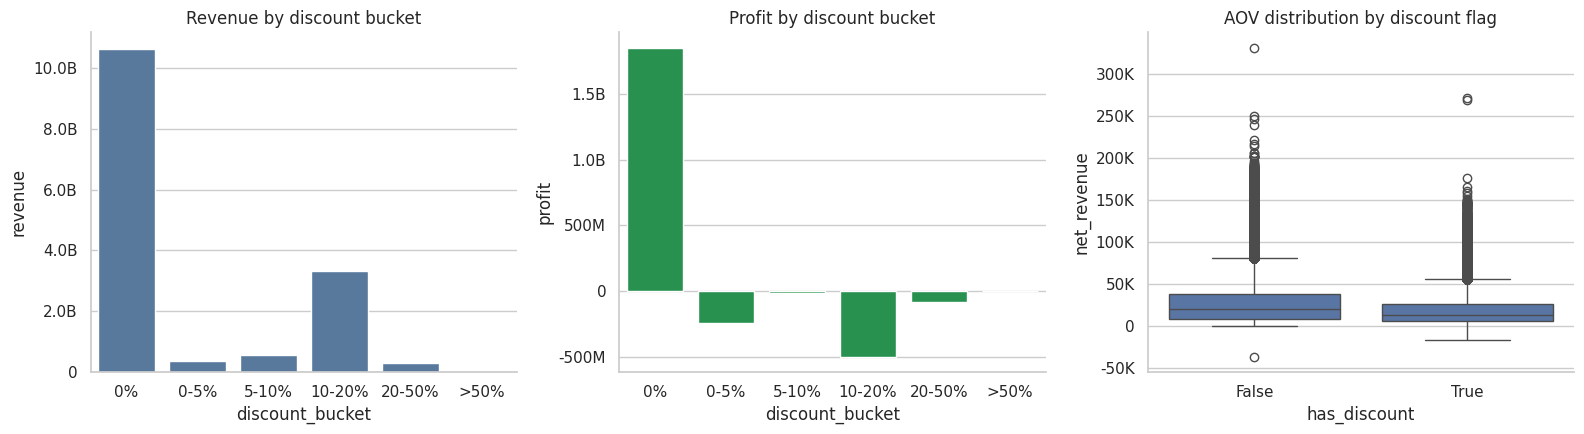

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=discount_bucket, x="discount_bucket", y="revenue", ax=axes[0], color="#4c78a8")
axes[0].set_title("Revenue by discount bucket"); axes[0].yaxis.set_major_formatter(money)
sns.barplot(data=discount_bucket, x="discount_bucket", y="profit", ax=axes[1], color="#16a34a")
axes[1].set_title("Profit by discount bucket"); axes[1].yaxis.set_major_formatter(money)
sns.boxplot(data=orders, x="has_discount", y="net_revenue", ax=axes[2])
axes[2].set_title("AOV distribution by discount flag"); axes[2].yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ scatter discount rate vs margin rate trên mẫu order. Cell này kiểm tra quan hệ trực quan giữa mức giảm giá và biên lợi nhuận.


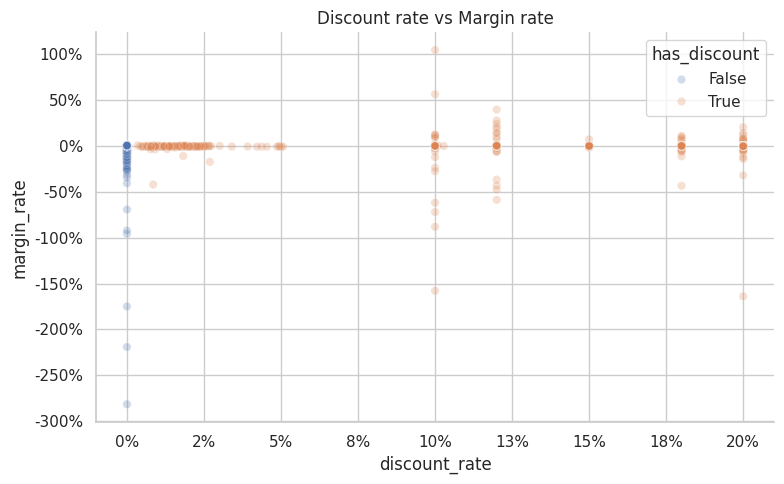

In [60]:
sample_orders = orders.sample(min(8000, len(orders)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample_orders, x="discount_rate", y="margin_rate", hue="has_discount", alpha=.25, ax=ax)
ax.set_title("Discount rate vs Margin rate")
ax.xaxis.set_major_formatter(pct_axis); ax.yaxis.set_major_formatter(pct_axis)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Tổng hợp discount theo category. Mục tiêu là xem danh mục nào dùng discount nhiều và discount đó ảnh hưởng margin ra sao.


,category,discount,gross_revenue,revenue,profit,orders,discount_rate,margin_rate
2,Outdoor,1.414860e+08,2.494883e+09,2.274679e+09,1.883166e+08,200454,0.056710,0.082788
0,Casual,2.036319e+07,4.606484e+08,4.262581e+08,1.971367e+07,23600,0.044205,0.046248
3,Streetwear,5.728693e+08,1.313135e+10,1.215171e+10,7.590416e+08,389543,0.043626,0.062464
1,GenZ,1.488892e+07,3.435991e+08,3.175604e+08,3.968661e+07,37054,0.043332,0.124973


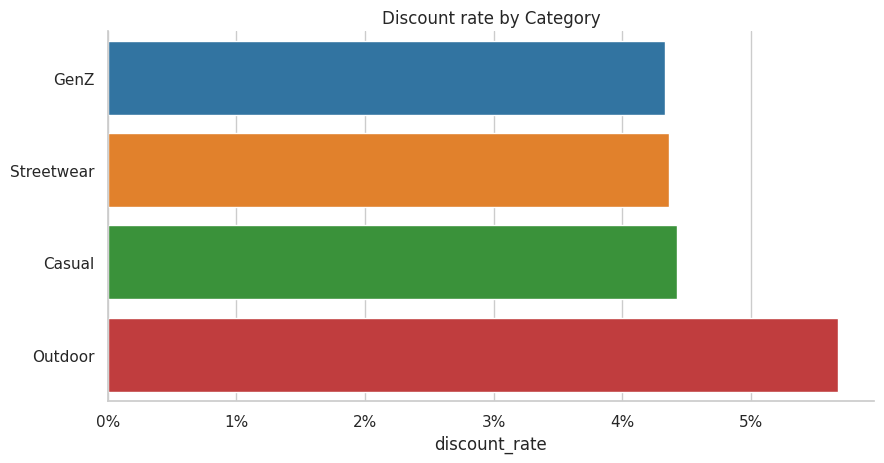

In [61]:
discount_category = items.groupby("category", as_index=False).agg(discount=("discount_amount", "sum"), gross_revenue=("gross_revenue", "sum"), revenue=("net_revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique")).assign(discount_rate=lambda d: d.discount / d.gross_revenue, margin_rate=lambda d: d.profit / d.revenue)
display(discount_category.sort_values("discount_rate", ascending=False))
barh(discount_category, "discount_rate", "category", "Discount rate by Category", formatter=pct_axis)

<!-- cell-note -->
**Mô tả cell:** Tổng kết Discount Impact. Note này nhấn mạnh cần so sánh cả AOV, profit và margin chứ không chỉ nhìn revenue.


In [78]:
show_note("Kết luận 3.3.6", [
    "Nhóm có discount cần được so sánh với nhóm không discount về AOV, profit và margin thay vì chỉ nhìn revenue.",
    "Nếu bucket discount cao có profit thấp/margin thấp, discount đang bào mòn hiệu quả tài chính.",
    "Nên phân tích thêm repeat purchase để biết discount tạo khách hàng dài hạn hay chỉ kéo đơn ngắn hạn.",
])

**Kết luận 3.3.6**
- Nhóm có discount cần được so sánh với nhóm không discount về AOV, profit và margin thay vì chỉ nhìn revenue.
- Nếu bucket discount cao có profit thấp/margin thấp, discount đang bào mòn hiệu quả tài chính.
- Nên phân tích thêm repeat purchase để biết discount tạo khách hàng dài hạn hay chỉ kéo đơn ngắn hạn.

### 3.3.7 — Return/Refund Impact

Mục tiêu: đo thất thoát do refund, category/product nào return cao, return có liên quan delivery delay/rating không, và gross revenue bị trừ thế nào để thành net revenue.

<!-- cell-note -->
**Mô tả cell:** Tổng hợp refund, return rate và returned units theo category. Đây là bảng nền để đo thất thoát do return/refund.


In [62]:
return_category = items.groupby("category", as_index=False).agg(revenue=("net_revenue", "sum"), gross_revenue=("gross_revenue", "sum"), refund=("refund_amount", "sum"), orders=("order_id", "nunique"), returned_lines=("is_returned", "sum"), units=("quantity", "sum"), returned_units=("return_quantity", "sum")).assign(return_rate=lambda d: d.returned_lines / d.orders, refund_to_revenue=lambda d: d.refund / d.revenue).sort_values("refund", ascending=False)
display(return_category)

,category,revenue,gross_revenue,refund,orders,returned_lines,units,returned_units,return_rate,refund_to_revenue
3,Streetwear,1.215171e+10,1.313135e+10,4.067659e+08,389543,21799,1768826,59812.0,0.055960,0.033474
2,Outdoor,2.274679e+09,2.494883e+09,7.871751e+07,200454,14720,1170000,40417.0,0.073433,0.034606
0,Casual,4.262581e+08,4.606484e+08,1.402709e+07,23600,1294,107469,3499.0,0.054831,0.032908
1,GenZ,3.175604e+08,3.435991e+08,1.114977e+07,37054,2126,166848,5873.0,0.057376,0.035111


<!-- cell-note -->
**Mô tả cell:** Vẽ refund amount và return rate theo category. Cell này tách danh mục mất tiền nhiều khỏi danh mục có tỷ lệ trả hàng cao.


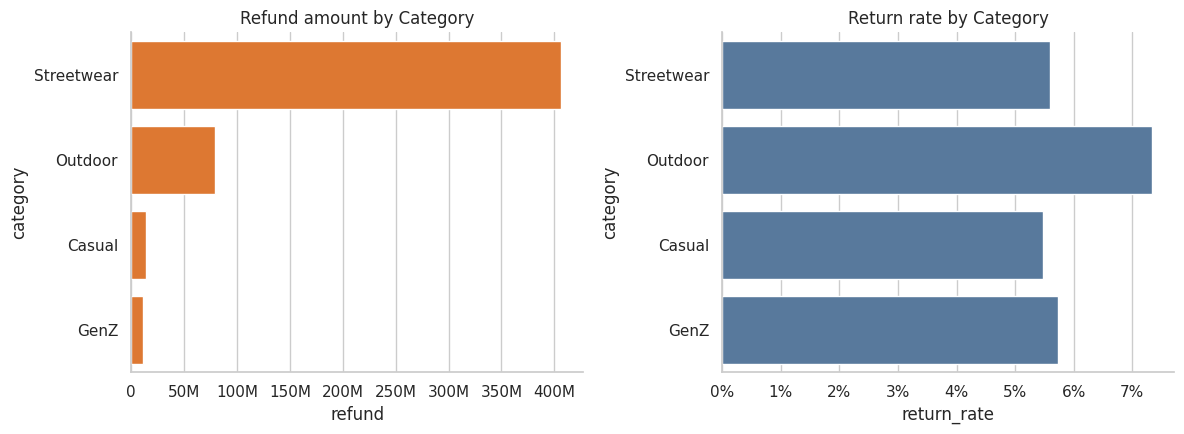

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=return_category, x="refund", y="category", ax=axes[0], color="#f97316")
axes[0].set_title("Refund amount by Category"); axes[0].xaxis.set_major_formatter(money)
sns.barplot(data=return_category, x="return_rate", y="category", ax=axes[1], color="#4c78a8")
axes[1].set_title("Return rate by Category"); axes[1].xaxis.set_major_formatter(pct_axis)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Vẽ financial bridge từ Gross Revenue qua Discount và Refund đến Net Revenue. Biểu đồ này mô tả trực quan dòng doanh thu bị trừ dần.


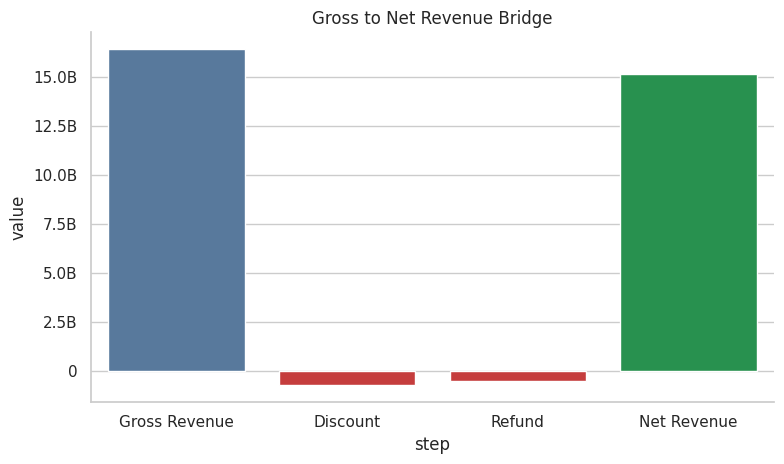

,step,value
0,Gross Revenue,1.643048e+10
1,Discount,-7.496073e+08
2,Refund,-5.106603e+08
3,Net Revenue,1.517021e+10


In [64]:
bridge = pd.DataFrame({"step": ["Gross Revenue", "Discount", "Refund", "Net Revenue"], "value": [orders.gross_revenue.sum(), -orders.discount_amount.sum(), -orders.refund_amount.sum(), orders.net_revenue.sum()]})
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=bridge, x="step", y="value", palette=["#4c78a8", "#dc2626", "#dc2626", "#16a34a"], ax=ax)
ax.set_title("Gross to Net Revenue Bridge"); ax.yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()
display(bridge)

<!-- cell-note -->
**Mô tả cell:** Tạo bảng return risk theo product, lọc sản phẩm có đủ volume. Cell này tránh kết luận từ sản phẩm có quá ít đơn.


In [65]:
return_product = items.groupby(["product_name", "category"], as_index=False).agg(revenue=("net_revenue", "sum"), refund=("refund_amount", "sum"), orders=("order_id", "nunique"), returned_lines=("is_returned", "sum")).assign(return_rate=lambda d: d.returned_lines / d.orders).query("orders >= 20").sort_values("return_rate", ascending=False)
display(return_product.head(25))

,product_name,category,revenue,refund,orders,returned_lines,return_rate
527,MekongFit UC-13,Streetwear,693806.47,78532.01,20,4,0.200000
1144,VietMode MA-34,Casual,304271.80,51225.12,21,4,0.190476
757,SaigonCore UR-08,Streetwear,463530.52,30040.20,23,4,0.173913
1100,UrbanVN UE-11,Streetwear,1037670.88,113483.34,30,5,0.166667
27,BambooCraft UM-09,Streetwear,1967721.87,229240.61,43,7,0.162791
630,NamStyle YY-26,GenZ,270218.59,19476.92,26,4,0.153846
1350,VietMotion RP-24,Outdoor,766199.84,46929.65,53,8,0.150943
733,SaigonCore UE-12,Streetwear,550432.06,43784.89,20,3,0.150000
19,BambooCraft UC-25,Streetwear,3242490.39,283914.45,103,15,0.145631
262,HanoiStreet UE-05,Streetwear,1120182.25,137585.72,28,4,0.142857


<!-- cell-note -->
**Mô tả cell:** Vẽ scatter product return risk giữa số đơn và return rate. Mục tiêu là tìm sản phẩm vừa nhiều volume vừa có tỷ lệ trả hàng cao.


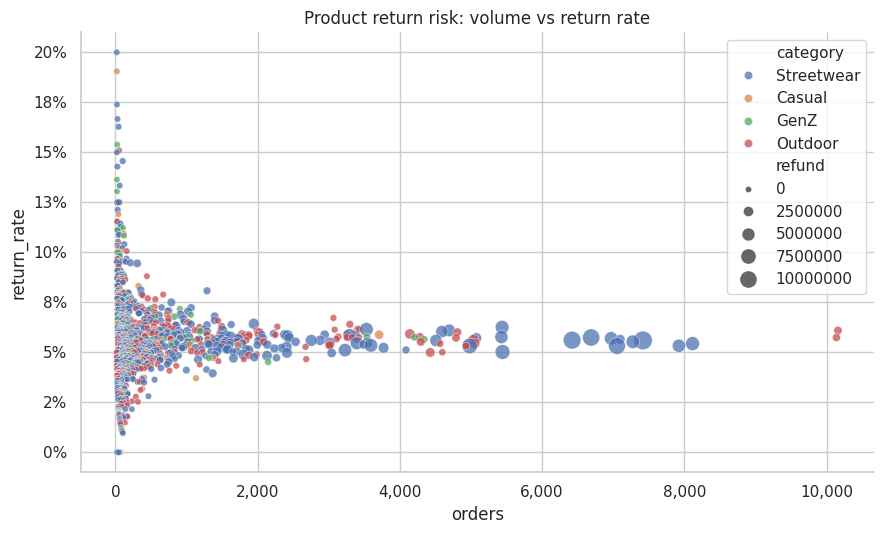

In [66]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=return_product, x="orders", y="return_rate", hue="category", size="refund", sizes=(20, 180), alpha=.75, ax=ax)
ax.set_title("Product return risk: volume vs return rate")
ax.yaxis.set_major_formatter(pct_axis); ax.xaxis.set_major_formatter(count_axis)
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** So sánh delivery days và rating giữa đơn returned/non-returned. Cell này kiểm tra return có liên quan vận chuyển hoặc trải nghiệm khách hàng không.


,is_returned,orders,avg_delivery_days,median_delivery_days,avg_rating
0,False,610883,4.500346,4.0,3.936309
1,True,36062,4.482502,4.0,NaN


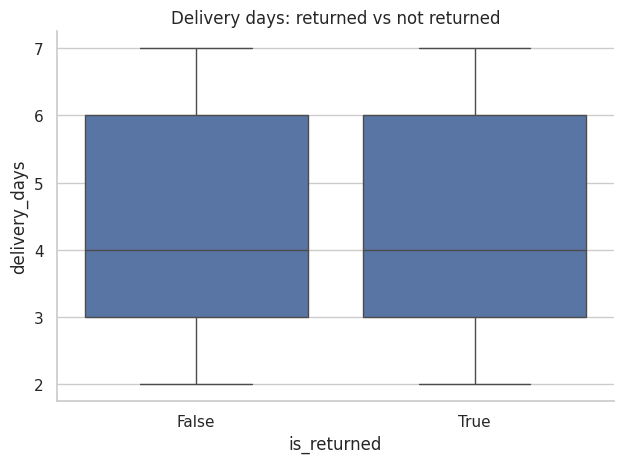

In [84]:
if "delivery_days" in orders:
    delivery_return = orders.groupby("is_returned").agg(orders=("order_id", "nunique"), avg_delivery_days=("delivery_days", "mean"), median_delivery_days=("delivery_days", "median"), avg_rating=("avg_rating", "mean")).reset_index()
    display(delivery_return)
    sns.boxplot(data=orders, x="is_returned", y="delivery_days")
    plt.title("Delivery days: returned vs not returned")
    plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Tổng kết Return/Refund Impact. Note này nêu mức refund làm giảm gross revenue và nhóm cần ưu tiên rà soát.


In [85]:
show_note("Kết luận 3.3.7", [
    f"Refund làm giảm {orders.refund_amount.sum() / orders.gross_revenue.sum():.2%} gross revenue.",
    f"Category refund lớn nhất là {return_category.iloc[0].category}.",
    "Product return risk cần ưu tiên sản phẩm vừa có return_rate cao vừa có đủ volume, không chỉ nhìn tỷ lệ trên mẫu nhỏ.",
])

**Kết luận 3.3.7**
- Refund làm giảm 3.11% gross revenue.
- Category refund lớn nhất là Streetwear.
- Product return risk cần ưu tiên sản phẩm vừa có return_rate cao vừa có đủ volume, không chỉ nhìn tỷ lệ trên mẫu nhỏ.

### 3.3.8 — Revenue Concentration / Pareto

Mục tiêu: kiểm tra 80/20, top product/customer đóng góp bao nhiêu doanh thu, và rủi ro phụ thuộc vào nhóm đầu bảng.

<!-- cell-note -->
**Mô tả cell:** Tạo bảng Pareto theo product và tính cumulative revenue share. Cell này đo mức độ tập trung doanh thu ở nhóm sản phẩm đầu bảng.


In [67]:
pareto_product = product[["product_name", "category", "revenue", "profit", "margin_rate"]].sort_values("revenue", ascending=False).reset_index(drop=True)
pareto_product["rank"] = pareto_product.index + 1
pareto_product["product_pct"] = pareto_product["rank"] / len(pareto_product)
pareto_product["cum_revenue_pct"] = pareto_product.revenue.cumsum() / pareto_product.revenue.sum()
product_pct_for_80 = pareto_product.loc[pareto_product.cum_revenue_pct >= .8, "product_pct"].iloc[0]
top_10_share = pareto_product.head(10).revenue.sum() / pareto_product.revenue.sum()
top_20pct_share = pareto_product.loc[pareto_product.product_pct <= .2, "revenue"].sum() / pareto_product.revenue.sum()
display(pareto_product.head(20))

,product_name,category,revenue,profit,margin_rate,rank,product_pct,cum_revenue_pct
0,SaigonFlex UM-92,Streetwear,3.682268e+08,1.255739e+06,0.003410,1,0.000694,0.024273
1,HanoiStreet UM-10,Streetwear,3.166296e+08,-3.400837e+07,-0.107407,2,0.001389,0.045145
2,SaigonFlex UM-43,Streetwear,3.153600e+08,1.051106e+08,0.333303,3,0.002083,0.065933
3,SaigonFlex UM-01,Streetwear,2.879669e+08,-2.432715e+07,-0.084479,4,0.002778,0.084915
4,SaigonFlex UM-80,Streetwear,2.485935e+08,2.057560e+07,0.082768,5,0.003472,0.101302
5,SaigonFlex UM-96,Streetwear,2.338790e+08,-2.338672e+07,-0.099995,6,0.004167,0.116719
6,SaigonFlex UC-69,Streetwear,1.928832e+08,4.164022e+07,0.215883,7,0.004861,0.129434
7,SaigonFlex UM-11,Streetwear,1.908530e+08,-1.788406e+07,-0.093706,8,0.005556,0.142015
8,UrbanVN UE-05,Streetwear,1.717334e+08,6.433148e+07,0.374601,9,0.006250,0.153335
9,SaigonFlex UM-54,Streetwear,1.701689e+08,-1.020554e+07,-0.059973,10,0.006944,0.164552


<!-- cell-note -->
**Mô tả cell:** Vẽ Pareto chart cho top product. Biểu đồ cho biết top sản phẩm đóng góp bao nhiêu và có gần quy luật 80/20 không.


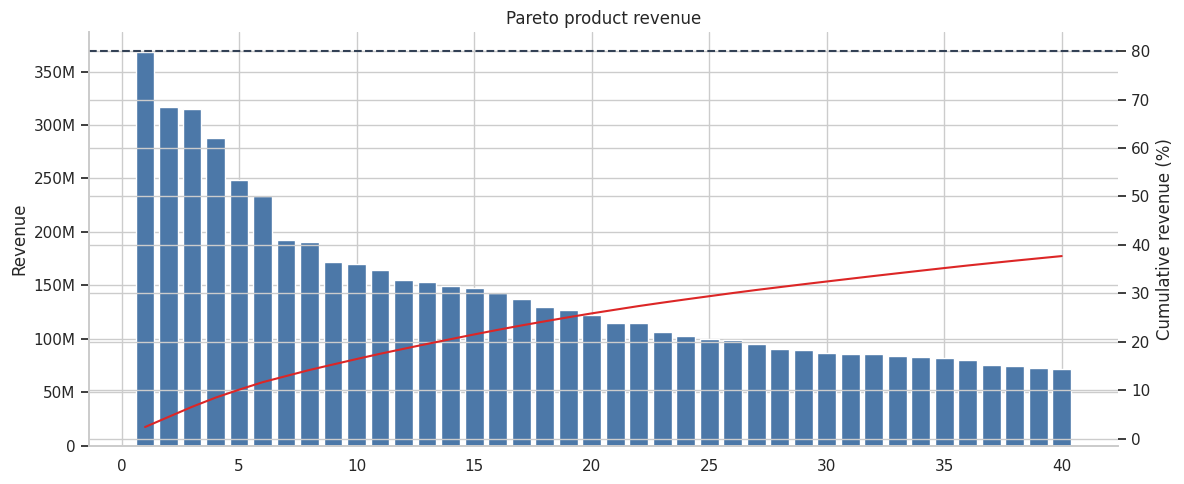

In [68]:
fig, ax1 = plt.subplots(figsize=(12, 5))
p = pareto_product.head(40)
ax1.bar(p["rank"], p["revenue"], color="#4c78a8")
ax1.set_ylabel("Revenue"); ax1.yaxis.set_major_formatter(money)
ax2 = ax1.twinx(); ax2.plot(p["rank"], p["cum_revenue_pct"] * 100, color="#dc2626"); ax2.axhline(80, color="#334155", linestyle="--")
ax2.set_ylabel("Cumulative revenue (%)")
ax1.set_title("Pareto product revenue")
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Tạo bảng Pareto theo customer. Mục tiêu là xem doanh thu có phụ thuộc vào một nhóm khách hàng lớn hay không.


In [70]:
customer_rev = orders.groupby("customer_id", as_index=False).agg(revenue=("net_revenue", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique")).sort_values("revenue", ascending=False).reset_index(drop=True)
customer_rev["rank"] = customer_rev.index + 1
customer_rev["customer_pct"] = customer_rev["rank"] / len(customer_rev)
customer_rev["cum_revenue_pct"] = customer_rev.revenue.cumsum() / customer_rev.revenue.sum()
display(customer_rev.head(20))

,customer_id,revenue,profit,orders,rank,customer_pct,cum_revenue_pct
0,13699,3282175.50,164981.339607,77,1,0.000011,0.000216
1,13698,3080752.75,304659.519631,73,2,0.000022,0.000419
2,13701,2848229.86,175590.491836,66,3,0.000033,0.000607
3,139815,2841225.49,434447.722218,68,4,0.000044,0.000794
4,139814,2783698.67,377845.658062,73,5,0.000055,0.000978
5,13697,2780854.22,136015.673936,74,6,0.000066,0.001161
6,13700,2693147.81,278467.994412,61,7,0.000078,0.001339
7,139816,2623253.48,296564.983961,69,8,0.000089,0.001512
8,139813,2503025.50,513387.845919,69,9,0.000100,0.001677
9,139812,2300899.14,357279.327804,58,10,0.000111,0.001828


<!-- cell-note -->
**Mô tả cell:** So sánh đường tích lũy doanh thu của product và customer. Cell này cho thấy rủi ro tập trung nằm ở sản phẩm hay khách hàng nhiều hơn.


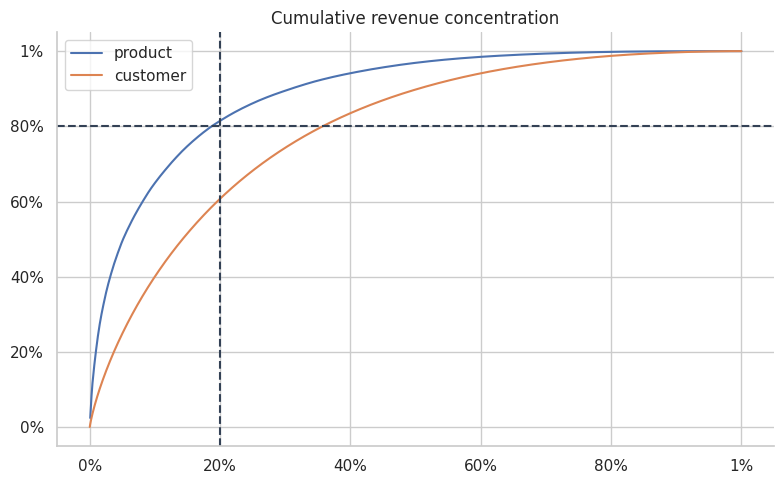

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pareto_product.product_pct, pareto_product.cum_revenue_pct, label="product")
ax.plot(customer_rev.customer_pct, customer_rev.cum_revenue_pct, label="customer")
ax.axhline(.8, color="#334155", linestyle="--"); ax.axvline(.2, color="#334155", linestyle="--")
ax.set_title("Cumulative revenue concentration")
ax.xaxis.set_major_formatter(pct_axis); ax.yaxis.set_major_formatter(pct_axis); ax.legend()
plt.tight_layout(); plt.show()

<!-- cell-note -->
**Mô tả cell:** Ghép top product với return risk để đánh giá rủi ro vận hành của nhóm chiến lược. Đây là bảng ưu tiên theo dõi tồn kho, chất lượng và refund.


In [72]:
top_risk = pareto_product.head(30).merge(return_product[["product_name", "return_rate", "refund"]], on="product_name", how="left")
display(top_risk[["product_name", "category", "revenue", "profit", "margin_rate", "return_rate", "refund"]])

,product_name,category,revenue,profit,margin_rate,return_rate,refund
0,SaigonFlex UM-92,Streetwear,3.682268e+08,1.255739e+06,0.003410,0.055945,12241878.26
1,HanoiStreet UM-10,Streetwear,3.166296e+08,-3.400837e+07,-0.107407,0.056057,10879460.50
2,SaigonFlex UM-43,Streetwear,3.153600e+08,1.051106e+08,0.333303,0.053169,9654909.83
3,SaigonFlex UM-01,Streetwear,2.879669e+08,-2.432715e+07,-0.084479,0.057399,10133931.30
4,SaigonFlex UM-80,Streetwear,2.485935e+08,2.057560e+07,0.082768,0.053191,7958581.64
5,SaigonFlex UM-96,Streetwear,2.338790e+08,-2.338672e+07,-0.099995,0.050147,7121041.39
6,SaigonFlex UC-69,Streetwear,1.928832e+08,4.164022e+07,0.215883,0.054344,6113477.47
7,SaigonFlex UM-11,Streetwear,1.908530e+08,-1.788406e+07,-0.093706,0.051099,5432011.43
8,UrbanVN UE-05,Streetwear,1.717334e+08,6.433148e+07,0.374601,0.053256,5302854.38
9,SaigonFlex UM-54,Streetwear,1.701689e+08,-1.020554e+07,-0.059973,0.053437,5672410.38


<!-- cell-note -->
**Mô tả cell:** Tổng kết Revenue Concentration/Pareto. Note này chốt mức đóng góp của top product và khuyến nghị quản trị rủi ro tập trung.


In [91]:
show_note("Kết luận 3.3.8", [
    f"Top 10 sản phẩm đóng góp {top_10_share:.1%} tổng revenue.",
    f"Top 20% sản phẩm đóng góp {top_20pct_share:.1%}; cần khoảng {product_pct_for_80:.1%} sản phẩm để đạt 80% revenue.",
    "Top product nên được quản trị như nhóm chiến lược: tồn kho, chất lượng, return_rate và margin cần theo dõi riêng.",
])

**Kết luận 3.3.8**
- Top 10 sản phẩm đóng góp 16.5% tổng revenue.
- Top 20% sản phẩm đóng góp 81.5%; cần khoảng 18.8% sản phẩm để đạt 80% revenue.
- Top product nên được quản trị như nhóm chiến lược: tồn kho, chất lượng, return_rate và margin cần theo dõi riêng.

## Executive Summary

**Thực trạng dòng tiền:** Notebook đã đo Gross Revenue, Net Revenue, Profit, Margin, AOV, median order value, revenue/customer và trend theo ngày/tháng. Khi doanh thu biến động, notebook tách theo orders và AOV để tránh kết luận mơ hồ.

**Điểm sáng & điểm nghẽn:** Product/category/channel được soi theo revenue, profit và margin. Discount và return/refund được tách riêng để thấy yếu tố nào bào mòn net revenue/profit.

**Khuyến nghị hành động:** Ưu tiên kênh/category vừa có revenue lớn vừa giữ margin tốt; kiểm soát discount bucket làm profit giảm; rà soát product có return_rate cao và đủ volume; theo dõi top products vì chúng vừa là nguồn revenue chiến lược vừa là rủi ro tập trung.